In [ ]:
!pip install -q -U ultralytics

In [ ]:
from ultralytics import YOLO

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_ROOT = Path(
    "/content/drive/MyDrive/Face_Cropping_Project"
)

DATASET_DIR = PROJECT_ROOT / "dataset"
IMAGE_DIR = DATASET_DIR / "images"
CSV_PATH = DATASET_DIR / "faces.csv"

OUTPUT_DIR = PROJECT_ROOT / "outputs"

YOLO_OUTPUT_DIR = OUTPUT_DIR / "yolo_detection"

YOLO_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Project:", PROJECT_ROOT)
print("Images:", IMAGE_DIR)
print("CSV:", CSV_PATH)
print("YOLO output:", YOLO_OUTPUT_DIR)

Project: /content/drive/MyDrive/Face_Cropping_Project
Images: /content/drive/MyDrive/Face_Cropping_Project/dataset/images
CSV: /content/drive/MyDrive/Face_Cropping_Project/dataset/faces.csv
YOLO output: /content/drive/MyDrive/Face_Cropping_Project/outputs/yolo_detection


In [ ]:
print("Images directory exists:", IMAGE_DIR.exists())
print("CSV exists:", CSV_PATH.exists())

print(
    "Number of images:",
    len(list(IMAGE_DIR.glob("*")))
)

Images directory exists: True
CSV exists: True
Number of images: 2204


In [ ]:
df = pd.read_csv(CSV_PATH)

print("Annotations:", len(df))
print("Unique images:", df["image_name"].nunique())

display(df.head())

Annotations: 3350
Unique images: 2204


,image_name,width,height,x0,y0,x1,y1
0,00001722.jpg,1333,2000,490,320,687,664
1,00001044.jpg,2000,1333,791,119,1200,436
2,00001050.jpg,667,1000,304,155,407,331
3,00001736.jpg,626,417,147,14,519,303
4,00003121.jpg,626,418,462,60,599,166


In [ ]:
sample_image_name = df.iloc[0]["image_name"]

sample_image_path = IMAGE_DIR / sample_image_name

print("Testing image:")
print(sample_image_path)

Testing image:
/content/drive/MyDrive/Face_Cropping_Project/dataset/images/00001722.jpg


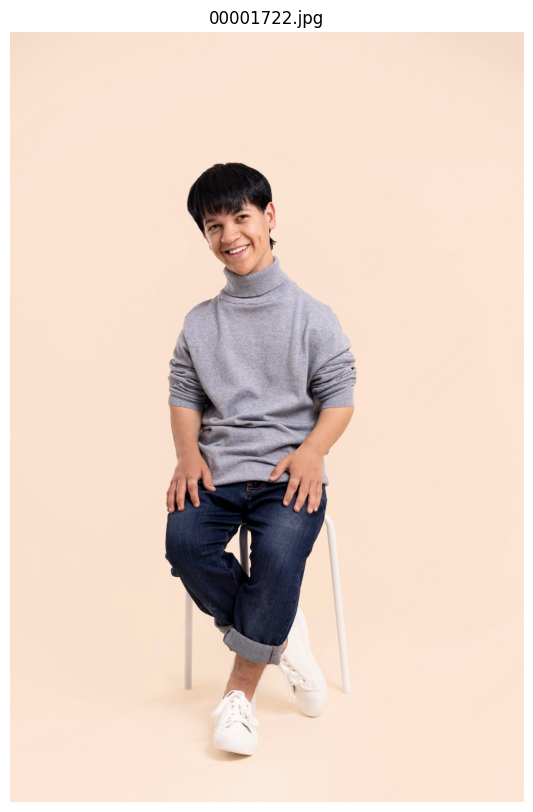

In [ ]:
image = Image.open(sample_image_path).convert("RGB")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis("off")
plt.title(sample_image_name)
plt.show()

In [ ]:
# Placeholder — we will set this after selecting the face-specific YOLO model
MODEL_PATH = None

print("MODEL_PATH will be set after selecting the pretrained YOLO face model.")

MODEL_PATH will be set after selecting the pretrained YOLO face model.


In [ ]:
# Download YOLO11n-face pretrained weights

!wget -q https://github.com/akanametov/yolo-face/releases/download/v0.0.0/yolov11n-face.pt \
    -O /content/yolov11n-face.pt

In [ ]:
MODEL_PATH = "/content/yolov11n-face.pt"

In [ ]:
model = YOLO(MODEL_PATH)
print("YOLO face model loaded successfully!")

TypeError: ERROR ❌️ /content/yolov11n-face.pt is not a loadable checkpoint — the file is empty, truncated or corrupted (EOFError: Ran out of input).
Recommended fixes are to re-download or re-export the file, or to run a command with an official Ultralytics model, i.e. 'yolo predict model=yolo26n.pt'

In [ ]:
from pathlib import Path

bad_model = Path("/content/yolov11n-face.pt")

if bad_model.exists():
    bad_model.unlink()

print("Old/corrupted model removed.")

Old/corrupted model removed.


In [ ]:
!wget -q --show-progress \
"https://github.com/YapaLab/yolo-face/releases/download/1.0.0/yolov11n-face.pt" \
-O /content/yolov11n-face.pt

/content/yolov11n-f 100%[===================>]   5.20M  --.-KB/s    in 0.05s   


In [ ]:
from pathlib import Path

MODEL_PATH = Path("/content/yolov11n-face.pt")

print("Model exists:", MODEL_PATH.exists())

if MODEL_PATH.exists():
    size_mb = MODEL_PATH.stat().st_size / (1024 * 1024)
    print(f"Model size: {size_mb:.2f} MB")

Model exists: True
Model size: 5.20 MB


In [ ]:
from ultralytics import YOLO

model = YOLO(str(MODEL_PATH))

print("YOLO11n-face loaded successfully!")

YOLO11n-face loaded successfully!


In [ ]:
print(model.names)

{0: 'face'}


In [ ]:
print("Model exists:", MODEL_PATH.exists())

if MODEL_PATH.exists():
    print(
        f"Model size: "
        f"{MODEL_PATH.stat().st_size / (1024 * 1024):.2f} MB"
    )

print("Model classes:", model.names)

Model exists: True
Model size: 5.20 MB
Model classes: {0: 'face'}


In [ ]:
results = model.predict(
    source=str(sample_image_path),
    conf=0.25,
    imgsz=1280,
    verbose=True
)


image 1/1 /content/drive/MyDrive/Face_Cropping_Project/dataset/images/00001722.jpg: 1280x864 1 face, 528.9ms
Speed: 19.8ms preprocess, 528.9ms inference, 1.4ms postprocess per image at shape (1, 3, 1280, 864)


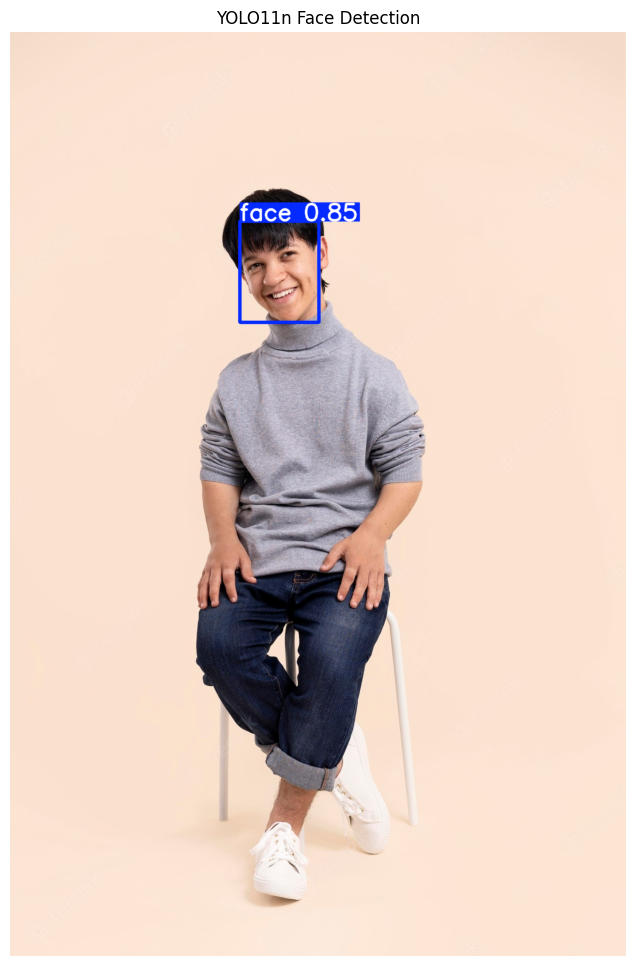

In [ ]:
result = results[0]

annotated_image = result.plot()

plt.figure(figsize=(12, 12))
plt.imshow(annotated_image[:, :, ::-1])
plt.axis("off")
plt.title("YOLO11n Face Detection")
plt.show()

In [ ]:
boxes = result.boxes

print("Number of faces detected:", len(boxes))

if len(boxes) > 0:

    xyxy = boxes.xyxy.cpu().numpy()
    confidence = boxes.conf.cpu().numpy()

    print("\nBounding boxes:")
    print(xyxy)

    print("\nConfidence scores:")
    print(confidence)

else:
    print("No faces detected.")

Number of faces detected: 1

Bounding boxes:
[[     497.37      409.17      668.69      628.96]]

Confidence scores:
[    0.85142]


In [ ]:
# Select 10 different images from the dataset

test_samples = (
    df["image_name"]
    .drop_duplicates()
    .sample(
        n=min(10, df["image_name"].nunique()),
        random_state=42
    )
    .tolist()
)

print("Selected images:")
for img in test_samples:
    print(img)

Selected images:
00000930.jpg
00001225.jpg
00001448.jpg
00002493.jpg
00003238.jpg
00001491.jpg
00003148.jpg
00001445.jpg
00003036.jpg
00001340.jpg


In [ ]:
test_results = []

for image_name in test_samples:

    image_path = IMAGE_DIR / image_name

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=1280,
        verbose=False
    )

    result = results[0]

    num_faces = len(result.boxes)

    if num_faces > 0:
        confidences = (
            result.boxes.conf
            .cpu()
            .numpy()
            .tolist()
        )

        max_confidence = max(confidences)
    else:
        confidences = []
        max_confidence = 0.0

    test_results.append({
        "image_name": image_name,
        "faces_detected": num_faces,
        "max_confidence": max_confidence
    })

test_results_df = pd.DataFrame(test_results)

display(test_results_df)

,image_name,faces_detected,max_confidence
0,00000930.jpg,1,0.878571
1,00001225.jpg,1,0.881008
2,00001448.jpg,1,0.878952
3,00002493.jpg,1,0.895819
4,00003238.jpg,1,0.883893
5,00001491.jpg,1,0.890586
6,00003148.jpg,1,0.887769
7,00001445.jpg,1,0.822341
8,00003036.jpg,1,0.889813
9,00001340.jpg,1,0.872131


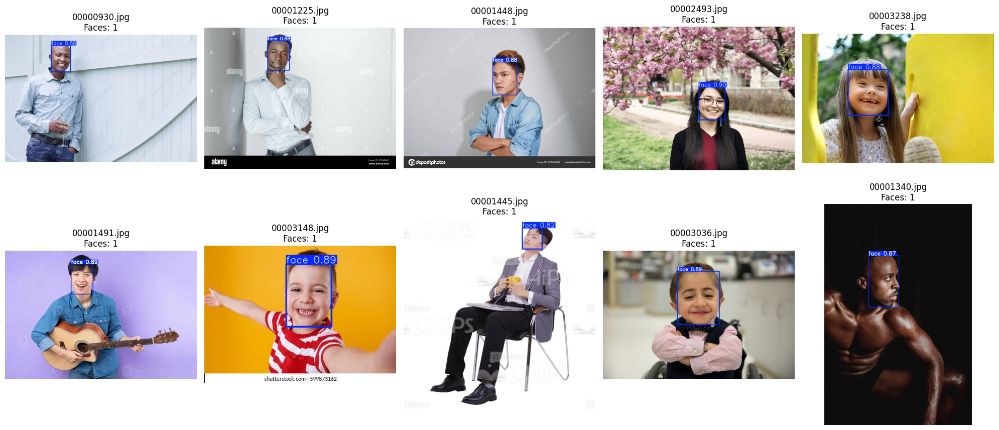

In [ ]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 9)
)

axes = axes.flatten()

for ax, image_name in zip(axes, test_samples):

    image_path = IMAGE_DIR / image_name

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=1280,
        verbose=False
    )

    result = results[0]

    annotated_image = result.plot()

    ax.imshow(annotated_image[:, :, ::-1])
    ax.set_title(
        f"{image_name}\n"
        f"Faces: {len(result.boxes)}"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Count annotated faces per image

face_counts = (
    df.groupby("image_name")
      .size()
      .sort_values(ascending=False)
)

multi_face_images = face_counts[face_counts >= 2]

print("Images containing 2+ annotated faces:",
      len(multi_face_images))

print("\nTop multi-face images:")
display(multi_face_images.head(20))

Images containing 2+ annotated faces: 491

Top multi-face images:


,0
image_name,
00000657.jpg,12
00003165.jpg,11
00003172.jpg,11
00000508.jpg,10
00003361.jpg,9
00000737.jpg,9
00000593.jpg,9
00000578.jpg,9
00000609.jpg,9


In [ ]:
multi_face_test_images = (
    multi_face_images
    .head(10)
    .index
    .tolist()
)

print("Selected multi-face images:")

for image_name in multi_face_test_images:
    print(
        image_name,
        "→",
        face_counts[image_name],
        "annotated faces"
    )

Selected multi-face images:
00000657.jpg → 12 annotated faces
00003165.jpg → 11 annotated faces
00003172.jpg → 11 annotated faces
00000508.jpg → 10 annotated faces
00003361.jpg → 9 annotated faces
00000737.jpg → 9 annotated faces
00000593.jpg → 9 annotated faces
00000578.jpg → 9 annotated faces
00000609.jpg → 9 annotated faces
00003069.jpg → 8 annotated faces


In [ ]:
multi_face_results = []

for image_name in multi_face_test_images:

    image_path = IMAGE_DIR / image_name

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=1280,
        verbose=False
    )

    result = results[0]

    detected_count = len(result.boxes)

    confidences = (
        result.boxes.conf.cpu().numpy().tolist()
        if detected_count > 0
        else []
    )

    multi_face_results.append({
        "image_name": image_name,
        "ground_truth_faces": face_counts[image_name],
        "yolo_faces_detected": detected_count,
        "confidence_scores": confidences
    })

multi_face_results_df = pd.DataFrame(
    multi_face_results
)

display(multi_face_results_df)

,image_name,ground_truth_faces,yolo_faces_detected,confidence_scores
0,00000657.jpg,12,25,"[0.8557336330413818, 0.8552919626235962, 0.854..."
1,00003165.jpg,11,16,"[0.8958464860916138, 0.8946043848991394, 0.893..."
2,00003172.jpg,11,16,"[0.8958464860916138, 0.8946043848991394, 0.893..."
3,00000508.jpg,10,16,"[0.9076067209243774, 0.8941799402236938, 0.893..."
4,00003361.jpg,9,9,"[0.892483651638031, 0.8922058939933777, 0.8880..."
5,00000737.jpg,9,23,"[0.8783275485038757, 0.8658179640769958, 0.865..."
6,00000593.jpg,9,12,"[0.906169056892395, 0.9031125903129578, 0.8954..."
7,00000578.jpg,9,13,"[0.889392077922821, 0.8854067921638489, 0.8846..."
8,00000609.jpg,9,10,"[0.8914433121681213, 0.8877747654914856, 0.882..."
9,00003069.jpg,8,8,"[0.9012989401817322, 0.8956598043441772, 0.886..."


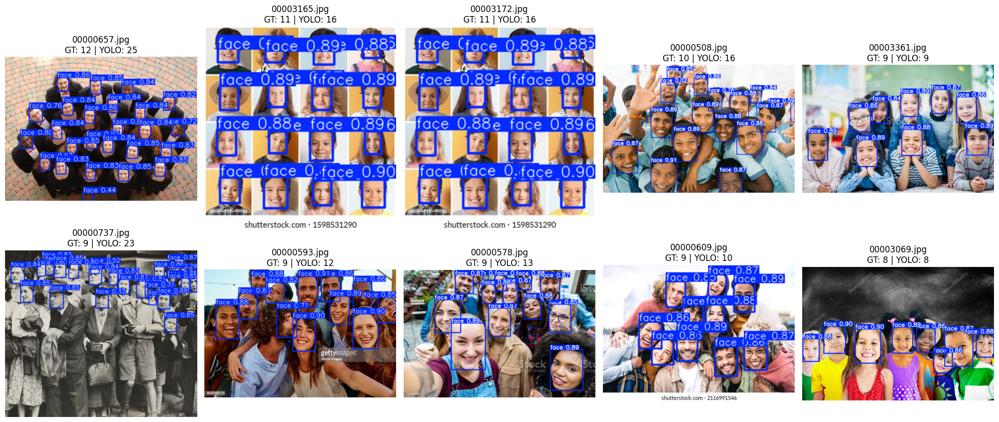

In [ ]:
fig, axes = plt.subplots(
    2,
    5,
    figsize=(20, 9)
)

axes = axes.flatten()

for ax, image_name in zip(
    axes,
    multi_face_test_images
):

    image_path = IMAGE_DIR / image_name

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=1280,
        verbose=False
    )

    result = results[0]

    annotated_image = result.plot()

    ax.imshow(
        annotated_image[:, :, ::-1]
    )

    ax.set_title(
        f"{image_name}\n"
        f"GT: {face_counts[image_name]} | "
        f"YOLO: {len(result.boxes)}"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
df["face_width"] = df["x1"] - df["x0"]
df["face_height"] = df["y1"] - df["y0"]

df["face_area"] = (
    df["face_width"] *
    df["face_height"]
)

small_faces = df.sort_values(
    "face_area"
).head(10)

display(
    small_faces[
        [
            "image_name",
            "width",
            "height",
            "face_width",
            "face_height",
            "face_area"
        ]
    ]
)

,image_name,width,height,face_width,face_height,face_area
2654,00003288.jpg,272,340,30,44,1320
1520,00003225.jpg,389,280,40,34,1360
2710,00003459.jpg,236,322,30,46,1380
2324,00003172.jpg,262,280,33,42,1386
2106,00003165.jpg,262,280,33,42,1386
2325,00003172.jpg,262,280,34,42,1428
1519,00003225.jpg,389,280,42,34,1428
2107,00003165.jpg,262,280,34,42,1428
2910,00003300.jpg,236,280,32,45,1440
220,00003450.jpg,236,353,29,51,1479


In [ ]:
def calculate_iou(box_a, box_b):
    """
    Calculate IoU between two boxes.

    Box format:
    [x1, y1, x2, y2]
    """

    ax1, ay1, ax2, ay2 = box_a
    bx1, by1, bx2, by2 = box_b

    # Intersection coordinates
    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    # Intersection dimensions
    iw = max(0, ix2 - ix1)
    ih = max(0, iy2 - iy1)

    intersection = iw * ih

    # Areas
    area_a = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    area_b = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = area_a + area_b - intersection

    if union == 0:
        return 0.0

    return intersection / union

In [ ]:
image_name = "00000657.jpg"

image_path = IMAGE_DIR / image_name

results = model.predict(
    source=str(image_path),
    conf=0.25,
    imgsz=1280,
    verbose=False
)

result = results[0]

pred_boxes = result.boxes.xyxy.cpu().numpy()
pred_conf = result.boxes.conf.cpu().numpy()

gt_rows = df[
    df["image_name"] == image_name
]

gt_boxes = gt_rows[
    ["x0", "y0", "x1", "y1"]
].values

print("Ground-truth faces:", len(gt_boxes))
print("YOLO detections:", len(pred_boxes))

Ground-truth faces: 12
YOLO detections: 25


In [ ]:
matches = []

for gt_index, gt_box in enumerate(gt_boxes):

    best_iou = 0.0
    best_prediction = None

    for pred_index, pred_box in enumerate(pred_boxes):

        iou = calculate_iou(
            gt_box,
            pred_box
        )

        if iou > best_iou:
            best_iou = iou
            best_prediction = pred_index

    matches.append({
        "gt_index": gt_index,
        "best_prediction": best_prediction,
        "best_iou": best_iou,
        "matched": best_iou >= 0.50
    })

matches_df = pd.DataFrame(matches)

display(matches_df)

,gt_index,best_prediction,best_iou,matched
0,0,8,0.469481,False
1,1,0,0.457505,False
2,2,1,0.442809,False
3,3,9,0.338440,False
4,4,7,0.457989,False
5,5,12,0.405599,False
6,6,19,0.411523,False
7,7,11,0.414996,False
8,8,3,0.399545,False
9,9,16,0.348105,False


In [ ]:
matched_count = matches_df["matched"].sum()

print(
    "Ground-truth faces:",
    len(gt_boxes)
)

print(
    "Matched faces:",
    matched_count
)

print(
    "Recall:",
    matched_count / len(gt_boxes)
)

print(
    "Unmatched ground-truth faces:",
    len(gt_boxes) - matched_count
)

Ground-truth faces: 12
Matched faces: 0
Recall: 0.0
Unmatched ground-truth faces: 12


In [ ]:
image_name = "00000657.jpg"

image_path = IMAGE_DIR / image_name

# Load image
from PIL import Image

img = Image.open(image_path)

print("Image dimensions:")
print("Width :", img.width)
print("Height:", img.height)

# Ground-truth boxes
gt_rows = df[df["image_name"] == image_name]
gt_boxes = gt_rows[["x0", "y0", "x1", "y1"]].values

# YOLO predictions
results = model.predict(
    source=str(image_path),
    conf=0.25,
    imgsz=1280,
    verbose=False
)

result = results[0]

pred_boxes = result.boxes.xyxy.cpu().numpy()
pred_conf = result.boxes.conf.cpu().numpy()

print("\nGround-truth boxes:")
for i, box in enumerate(gt_boxes):
    print(f"GT {i:02d}: {box}")

print("\nYOLO prediction boxes:")
for i, (box, conf) in enumerate(zip(pred_boxes, pred_conf)):
    print(f"Pred {i:02d}: {box} | confidence = {conf:.4f}")

Image dimensions:
Width : 600
Height: 450

Ground-truth boxes:
GT 00: [407 204 466 255]
GT 01: [154  55 212 105]
GT 02: [234 158 291 208]
GT 03: [131 204 198 261]
GT 04: [167 134 223 184]
GT 05: [323 200 379 249]
GT 06: [237 241 294 292]
GT 07: [290 250 347 299]
GT 08: [368 267 429 321]
GT 09: [471 271 532 326]
GT 10: [453 323 510 373]
GT 11: [341 342 396 390]

YOLO prediction boxes:
Pred 00: [     163.92      65.293      198.91      108.91] | confidence = 0.8557
Pred 01: [     248.05      167.21      279.11      208.37] | confidence = 0.8553
Pred 02: [     266.92      74.272      299.38      116.72] | confidence = 0.8548
Pred 03: [     380.97      278.25      414.65      317.33] | confidence = 0.8537
Pred 04: [     192.52      270.04      223.19      307.23] | confidence = 0.8525
Pred 05: [     467.39       330.4      499.87      373.17] | confidence = 0.8523
Pred 06: [     354.27      351.96      385.56      388.52] | confidence = 0.8476
Pred 07: [     179.74       143.7      212.99 

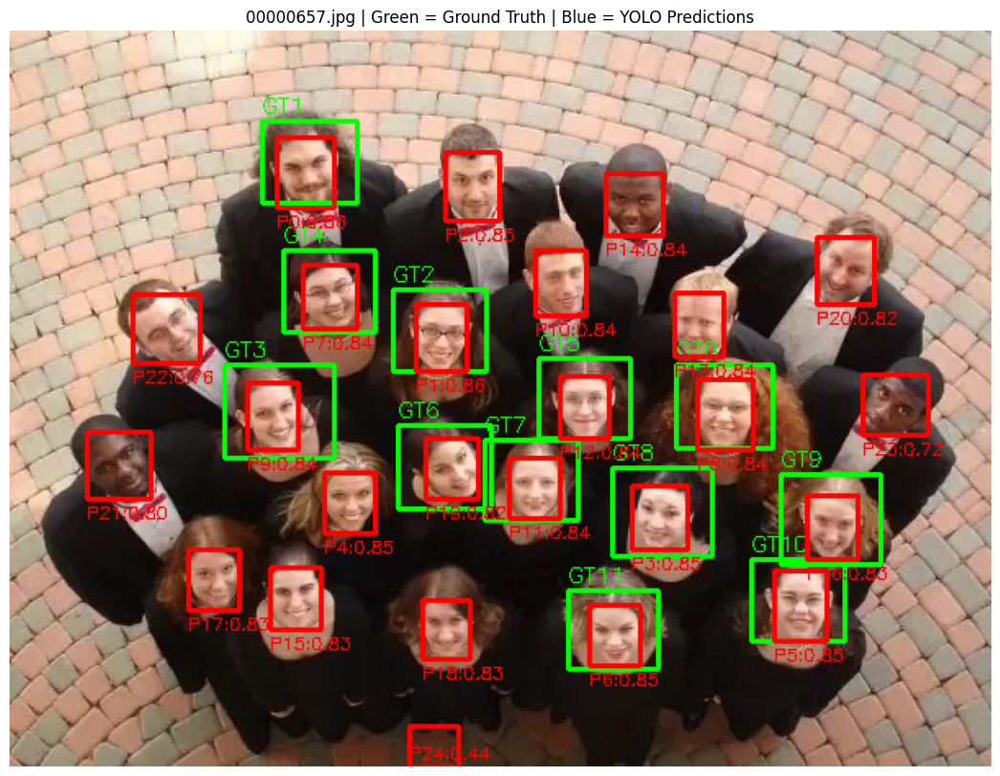

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image_name = "00000657.jpg"
image_path = IMAGE_DIR / image_name

# Read image
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Get ground-truth boxes
gt_rows = df[df["image_name"] == image_name]
gt_boxes = gt_rows[["x0", "y0", "x1", "y1"]].values

# YOLO predictions
results = model.predict(
    source=str(image_path),
    conf=0.25,
    imgsz=1280,
    verbose=False
)

result = results[0]

pred_boxes = result.boxes.xyxy.cpu().numpy()
pred_conf = result.boxes.conf.cpu().numpy()

# Draw GT boxes
visualization = image.copy()

for i, box in enumerate(gt_boxes):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(
        visualization,
        (x1, y1),
        (x2, y2),
        (0, 255, 0),   # Green = Ground Truth
        2
    )

    cv2.putText(
        visualization,
        f"GT{i}",
        (x1, max(y1 - 5, 10)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.45,
        (0, 255, 0),
        1
    )

# Draw YOLO predictions
for i, (box, conf) in enumerate(zip(pred_boxes, pred_conf)):
    x1, y1, x2, y2 = map(int, box)

    cv2.rectangle(
        visualization,
        (x1, y1),
        (x2, y2),
        (255, 0, 0),   # Blue = YOLO
        2
    )

    cv2.putText(
        visualization,
        f"P{i}:{conf:.2f}",
        (x1, min(y2 + 12, image.shape[0] - 5)),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.35,
        (255, 0, 0),
        1
    )

# Display
plt.figure(figsize=(14, 10))
plt.imshow(visualization)
plt.title(
    f"{image_name} | Green = Ground Truth | Blue = YOLO Predictions"
)
plt.axis("off")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# Use the same multi-face images we tested earlier
test_images = [
    "00000657.jpg",
    "00003165.jpg",
    "00003172.jpg",
    "00000508.jpg",
    "00003361.jpg",
    "00000737.jpg",
    "00000593.jpg",
    "00000578.jpg",
    "00000609.jpg",
    "00003069.jpg"
]

confidence_thresholds = [0.25, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for conf_threshold in confidence_thresholds:

    for image_name in test_images:

        image_path = IMAGE_DIR / image_name

        results = model.predict(
            source=str(image_path),
            conf=conf_threshold,
            imgsz=1280,
            verbose=False
        )

        result = results[0]

        confidences = result.boxes.conf.cpu().numpy()

        threshold_results.append({
            "confidence_threshold": conf_threshold,
            "image_name": image_name,
            "detections": len(confidences),
            "mean_confidence": (
                float(np.mean(confidences))
                if len(confidences) > 0 else 0
            ),
            "min_confidence": (
                float(np.min(confidences))
                if len(confidences) > 0 else 0
            ),
            "max_confidence": (
                float(np.max(confidences))
                if len(confidences) > 0 else 0
            )
        })

threshold_df = pd.DataFrame(threshold_results)

display(threshold_df)

,confidence_threshold,image_name,detections,mean_confidence,min_confidence,max_confidence
0,0.25,00000657.jpg,25,0.815565,0.443666,0.855734
1,0.25,00003165.jpg,16,0.881193,0.856285,0.895846
2,0.25,00003172.jpg,16,0.881193,0.856285,0.895846
3,0.25,00000508.jpg,16,0.847083,0.592305,0.907607
4,0.25,00003361.jpg,9,0.875375,0.844876,0.892484
5,0.25,00000737.jpg,23,0.764086,0.287607,0.878328
6,0.25,00000593.jpg,12,0.859664,0.707468,0.906169
7,0.25,00000578.jpg,13,0.869070,0.815857,0.889392
8,0.25,00000609.jpg,10,0.863357,0.806646,0.891443
9,0.25,00003069.jpg,8,0.878867,0.855622,0.901299


In [ ]:
summary = (
    threshold_df
    .groupby("confidence_threshold")
    .agg(
        total_detections=("detections", "sum"),
        average_detections=("detections", "mean"),
        average_confidence=("mean_confidence", "mean"),
        lowest_confidence=("min_confidence", "min"),
        highest_confidence=("max_confidence", "max")
    )
    .reset_index()
)

display(summary)

,confidence_threshold,total_detections,average_detections,average_confidence,lowest_confidence,highest_confidence
0,0.25,148,14.8,0.853545,0.287607,0.907607
1,0.40,146,14.6,0.857979,0.443666,0.907607
2,0.50,144,14.4,0.861284,0.522863,0.907607
3,0.60,142,14.2,0.864578,0.707468,0.907607
4,0.70,142,14.2,0.864578,0.707468,0.907607


In [ ]:
single_face_images = [
    "00000930.jpg",
    "00001225.jpg",
    "00001448.jpg",
    "00002493.jpg",
    "00003238.jpg",
    "00001491.jpg",
    "00003148.jpg",
    "00001445.jpg",
    "00003036.jpg",
    "00001340.jpg"
]

comparison_results = []

for image_name in single_face_images:

    image_path = IMAGE_DIR / image_name

    row = {
        "image_name": image_name
    }

    for conf_threshold in [0.25, 0.60]:

        results = model.predict(
            source=str(image_path),
            conf=conf_threshold,
            imgsz=1280,
            verbose=False
        )

        result = results[0]

        confidences = result.boxes.conf.cpu().numpy()

        row[f"detections_{conf_threshold}"] = len(confidences)

        row[f"max_conf_{conf_threshold}"] = (
            float(np.max(confidences))
            if len(confidences) > 0 else 0
        )

    comparison_results.append(row)

comparison_df = pd.DataFrame(comparison_results)

display(comparison_df)

,image_name,detections_0.25,max_conf_0.25,detections_0.6,max_conf_0.6
0,00000930.jpg,1,0.878571,1,0.878571
1,00001225.jpg,1,0.881008,1,0.881008
2,00001448.jpg,1,0.878952,1,0.878952
3,00002493.jpg,1,0.895819,1,0.895819
4,00003238.jpg,1,0.883893,1,0.883893
5,00001491.jpg,1,0.890586,1,0.890586
6,00003148.jpg,1,0.887769,1,0.887769
7,00001445.jpg,1,0.822341,1,0.822341
8,00003036.jpg,1,0.889813,1,0.889813
9,00001340.jpg,1,0.872131,1,0.872131


In [ ]:
# Calculate ground-truth face dimensions and area
small_face_df = df.copy()

small_face_df["face_width"] = small_face_df["x1"] - small_face_df["x0"]
small_face_df["face_height"] = small_face_df["y1"] - small_face_df["y0"]
small_face_df["face_area"] = (
    small_face_df["face_width"] *
    small_face_df["face_height"]
)

# Sort by face area: smallest faces first
small_face_df = small_face_df.sort_values("face_area")

# Select unique images containing small faces
small_face_images = []

for image_name in small_face_df["image_name"]:
    if image_name not in small_face_images:
        small_face_images.append(image_name)

    if len(small_face_images) == 10:
        break

print("Selected small-face images:\n")

for image_name in small_face_images:
    rows = small_face_df[
        small_face_df["image_name"] == image_name
    ]

    smallest_area = rows["face_area"].min()
    smallest_width = rows.loc[
        rows["face_area"].idxmin(), "face_width"
    ]
    smallest_height = rows.loc[
        rows["face_area"].idxmin(), "face_height"
    ]

    print(
        f"{image_name} | "
        f"smallest face = "
        f"{smallest_width:.0f} x {smallest_height:.0f} "
        f"| area = {smallest_area:.0f}"
    )

Selected small-face images:

00003288.jpg | smallest face = 30 x 44 | area = 1320
00003225.jpg | smallest face = 40 x 34 | area = 1360
00003459.jpg | smallest face = 30 x 46 | area = 1380
00003172.jpg | smallest face = 33 x 42 | area = 1386
00003165.jpg | smallest face = 33 x 42 | area = 1386
00003300.jpg | smallest face = 32 x 45 | area = 1440
00003450.jpg | smallest face = 29 x 51 | area = 1479
00002356.jpg | smallest face = 38 x 39 | area = 1482
00003496.jpg | smallest face = 31 x 48 | area = 1488
00003416.jpg | smallest face = 30 x 50 | area = 1500


In [ ]:
small_face_comparison = []

for image_name in small_face_images:

    image_path = IMAGE_DIR / image_name

    # Ground-truth faces for this image
    gt_rows = df[df["image_name"] == image_name]

    row = {
        "image_name": image_name,
        "gt_faces": len(gt_rows)
    }

    for conf_threshold in [0.25, 0.60]:

        results = model.predict(
            source=str(image_path),
            conf=conf_threshold,
            imgsz=1280,
            verbose=False
        )

        result = results[0]

        confidences = result.boxes.conf.cpu().numpy()

        row[f"detections_{conf_threshold}"] = len(confidences)

        row[f"min_conf_{conf_threshold}"] = (
            float(np.min(confidences))
            if len(confidences) > 0 else 0
        )

        row[f"max_conf_{conf_threshold}"] = (
            float(np.max(confidences))
            if len(confidences) > 0 else 0
        )

    small_face_comparison.append(row)

small_face_comparison_df = pd.DataFrame(
    small_face_comparison
)

display(small_face_comparison_df)

,image_name,gt_faces,detections_0.25,min_conf_0.25,max_conf_0.25,detections_0.6,min_conf_0.6,max_conf_0.6
0,00003288.jpg,1,1,0.860863,0.860863,1,0.860863,0.860863
1,00003225.jpg,2,5,0.411789,0.863711,4,0.844054,0.863711
2,00003459.jpg,1,2,0.811142,0.870981,2,0.811142,0.870981
3,00003172.jpg,11,16,0.856285,0.895846,16,0.856285,0.895846
4,00003165.jpg,11,16,0.856285,0.895846,16,0.856285,0.895846
5,00003300.jpg,1,1,0.853294,0.853294,1,0.853294,0.853294
6,00003450.jpg,2,5,0.838253,0.868797,5,0.838253,0.868797
7,00002356.jpg,1,3,0.655413,0.849707,3,0.655413,0.849707
8,00003496.jpg,1,5,0.362154,0.878264,4,0.822378,0.878264
9,00003416.jpg,2,3,0.842659,0.870910,3,0.842659,0.870910


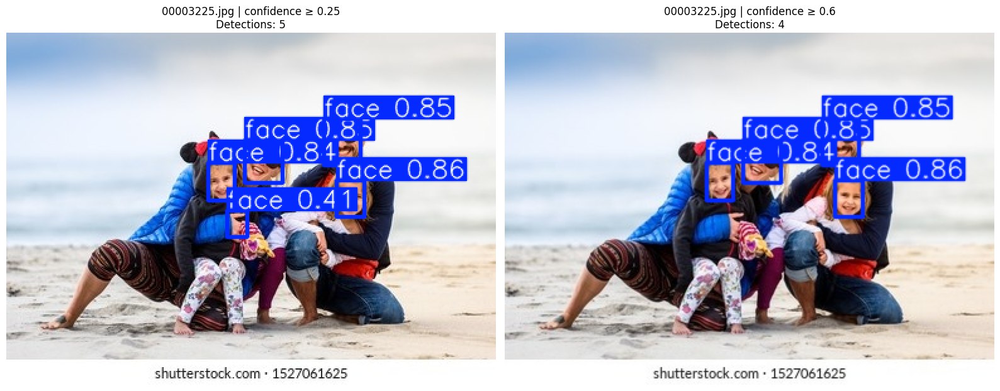

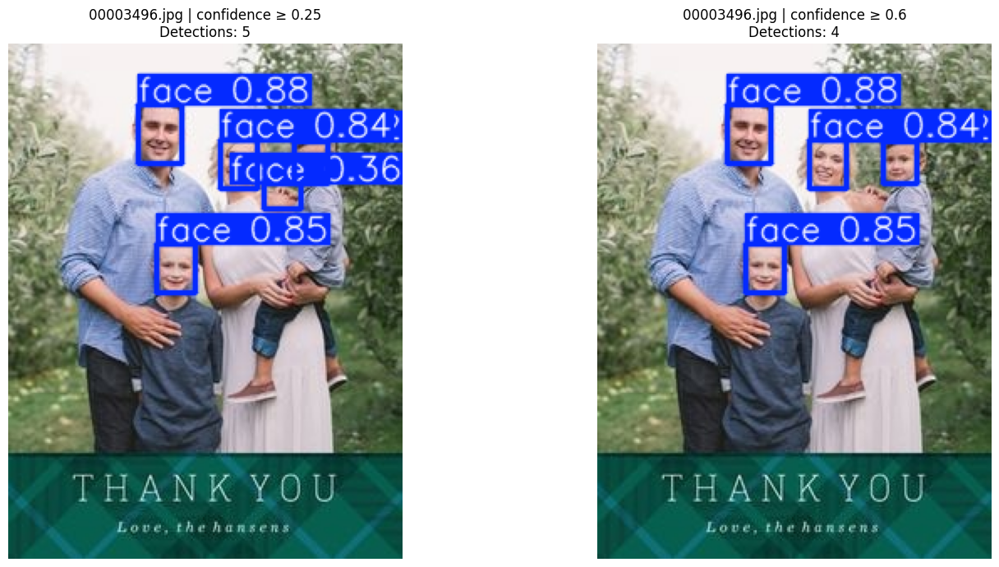

In [ ]:
import cv2
import matplotlib.pyplot as plt

borderline_images = [
    "00003225.jpg",
    "00003496.jpg"
]

for image_name in borderline_images:

    image_path = IMAGE_DIR / image_name

    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    for ax, conf_threshold in zip(axes, [0.25, 0.60]):

        results = model.predict(
            source=str(image_path),
            conf=conf_threshold,
            imgsz=1280,
            verbose=False
        )

        result = results[0]

        # YOLO annotated image
        annotated = result.plot()

        # Convert BGR → RGB
        annotated = cv2.cvtColor(
            annotated,
            cv2.COLOR_BGR2RGB
        )

        detections = len(result.boxes)

        ax.imshow(annotated)
        ax.set_title(
            f"{image_name} | confidence ≥ {conf_threshold}\n"
            f"Detections: {detections}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

# Representative images from our experiments
sample_crop_images = [
    "00000930.jpg",   # single face
    "00000657.jpg",   # many faces
    "00003225.jpg",   # small faces
    "00003496.jpg"    # small faces
]

SAMPLE_CROP_DIR = OUTPUT_DIR / "sample_crops"
SAMPLE_CROP_DIR.mkdir(parents=True, exist_ok=True)

crop_records = []

for image_name in sample_crop_images:

    image_path = IMAGE_DIR / image_name

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=1280,
        verbose=False
    )

    result = results[0]

    image = Image.open(image_path).convert("RGB")

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    image_crop_dir = SAMPLE_CROP_DIR / Path(image_name).stem
    image_crop_dir.mkdir(parents=True, exist_ok=True)

    print(f"\n{image_name}: {len(boxes)} faces detected")

    for i, (box, conf) in enumerate(zip(boxes, confidences)):

        x1, y1, x2, y2 = box

        # Clip coordinates to image boundaries
        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(image.width, int(x2))
        y2 = min(image.height, int(y2))

        # Skip invalid boxes
        if x2 <= x1 or y2 <= y1:
            continue

        crop = image.crop((x1, y1, x2, y2))

        crop_path = image_crop_dir / f"face_{i:03d}.jpg"
        crop.save(crop_path, quality=95)

        crop_records.append({
            "image_name": image_name,
            "face_index": i,
            "confidence": float(conf),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "crop_width": x2 - x1,
            "crop_height": y2 - y1,
            "crop_path": str(crop_path)
        })

crop_df = pd.DataFrame(crop_records)

print("\nTotal crops generated:", len(crop_df))

display(crop_df)


00000930.jpg: 1 faces detected

00000657.jpg: 25 faces detected

00003225.jpg: 5 faces detected

00003496.jpg: 5 faces detected

Total crops generated: 36


,image_name,face_index,confidence,x1,y1,x2,y2,crop_width,crop_height,crop_path
0,00000930.jpg,0,0.878571,193,46,272,156,79,110,/content/drive/MyDrive/Face_Cropping_Project/o...
1,00000657.jpg,0,0.855734,163,65,198,108,35,43,/content/drive/MyDrive/Face_Cropping_Project/o...
2,00000657.jpg,1,0.855292,248,167,279,208,31,41,/content/drive/MyDrive/Face_Cropping_Project/o...
3,00000657.jpg,2,0.854767,266,74,299,116,33,42,/content/drive/MyDrive/Face_Cropping_Project/o...
4,00000657.jpg,3,0.853717,380,278,414,317,34,39,/content/drive/MyDrive/Face_Cropping_Project/o...
5,00000657.jpg,4,0.852461,192,270,223,307,31,37,/content/drive/MyDrive/Face_Cropping_Project/o...
6,00000657.jpg,5,0.852253,467,330,499,373,32,43,/content/drive/MyDrive/Face_Cropping_Project/o...
7,00000657.jpg,6,0.847558,354,351,385,388,31,37,/content/drive/MyDrive/Face_Cropping_Project/o...
8,00000657.jpg,7,0.844139,179,143,212,182,33,39,/content/drive/MyDrive/Face_Cropping_Project/o...
9,00000657.jpg,8,0.843879,420,213,454,256,34,43,/content/drive/MyDrive/Face_Cropping_Project/o...


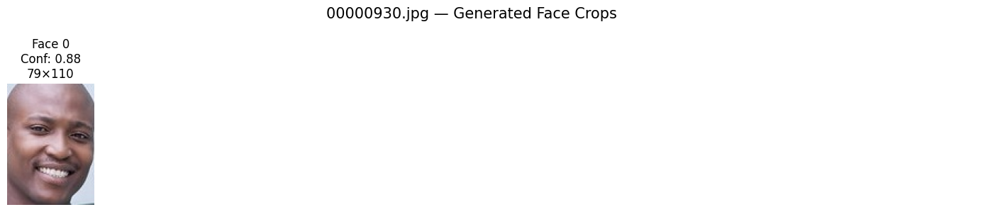

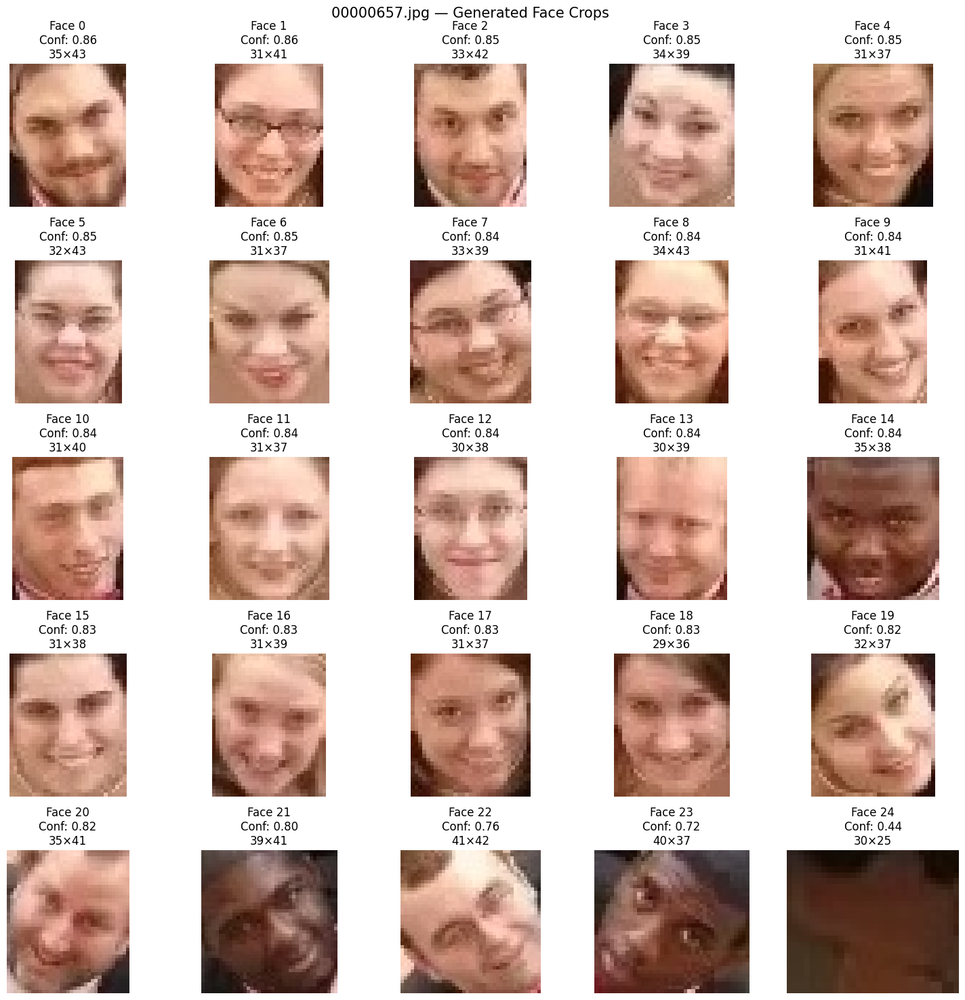

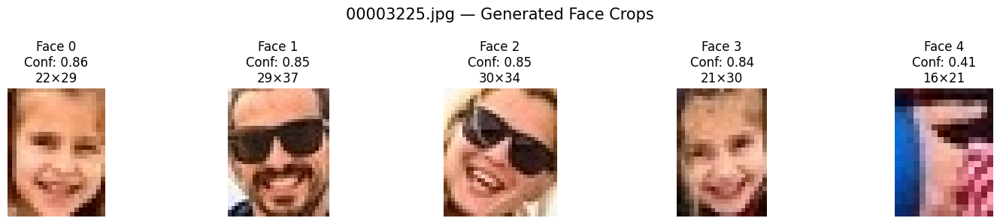

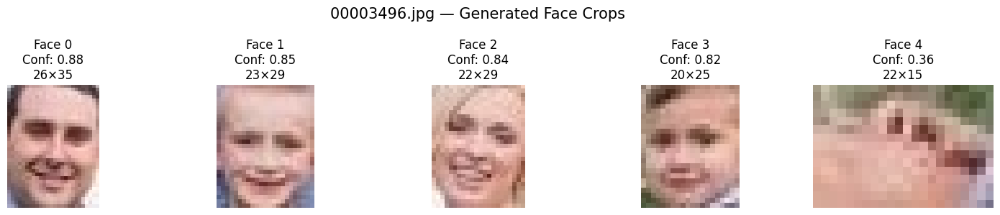

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

for image_name in sample_crop_images:

    image_crop_dir = SAMPLE_CROP_DIR / Path(image_name).stem

    crop_files = sorted(image_crop_dir.glob("*.jpg"))

    if not crop_files:
        continue

    # Limit the number shown at once for readability
    max_display = min(len(crop_files), 30)

    cols = 5
    rows = (max_display + cols - 1) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    # Make axes always iterable
    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, crop_path in enumerate(crop_files[:max_display]):

        crop = Image.open(crop_path)

        # Find metadata
        metadata = crop_df[
            (crop_df["image_name"] == image_name) &
            (crop_df["face_index"] == i)
        ]

        if len(metadata) > 0:
            confidence = metadata.iloc[0]["confidence"]
            width = metadata.iloc[0]["crop_width"]
            height = metadata.iloc[0]["crop_height"]

            title = (
                f"Face {i}\n"
                f"Conf: {confidence:.2f}\n"
                f"{width}×{height}"
            )
        else:
            title = f"Face {i}"

        ax = axes[i]
        ax.imshow(crop)
        ax.set_title(title)
        ax.axis("off")

    fig.suptitle(
        f"{image_name} — Generated Face Crops",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

In [ ]:
from pathlib import Path
from PIL import Image
import pandas as pd
import numpy as np


# Final detector configuration
FINAL_CONFIDENCE = 0.60
FINAL_IMAGE_SIZE = 1280


def detect_and_crop_faces(
    image_path,
    model,
    output_dir,
    confidence=FINAL_CONFIDENCE,
    imgsz=FINAL_IMAGE_SIZE
):
    """
    Detect faces in an image using YOLO11n-face
    and save each detected face as a separate crop.

    Returns:
        DataFrame containing detection and crop metadata.
    """

    image_path = Path(image_path)
    output_dir = Path(output_dir)

    output_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Run YOLO inference
    results = model.predict(
        source=str(image_path),
        conf=confidence,
        imgsz=imgsz,
        verbose=False
    )

    result = results[0]

    # Extract predictions
    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    records = []

    for face_id, (box, conf) in enumerate(
        zip(boxes, confidences)
    ):

        x1, y1, x2, y2 = box

        # Convert to integer coordinates
        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(image.width, int(x2))
        y2 = min(image.height, int(y2))

        # Validate bounding box
        if x2 <= x1 or y2 <= y1:
            continue

        crop_width = x2 - x1
        crop_height = y2 - y1

        # Extract crop
        crop = image.crop(
            (x1, y1, x2, y2)
        )

        # Create image-specific directory
        image_output_dir = (
            output_dir / image_path.stem
        )

        image_output_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        # Save crop
        crop_filename = (
            f"face_{face_id:03d}.jpg"
        )

        crop_path = (
            image_output_dir /
            crop_filename
        )

        crop.save(
            crop_path,
            quality=95
        )

        records.append({
            "image_name": image_path.name,
            "face_id": face_id,
            "confidence": float(conf),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "crop_width": crop_width,
            "crop_height": crop_height,
            "crop_path": str(crop_path)
        })

    return pd.DataFrame(records)

In [ ]:
# Test images representing different scenarios
test_crop_images = [
    "00000930.jpg",   # single face
    "00000657.jpg",   # many faces
    "00003225.jpg",   # small faces
    "00003496.jpg"    # small faces
]

# Production test output directory
TEST_CROP_DIR = OUTPUT_DIR / "production_test_crops"
TEST_CROP_DIR.mkdir(parents=True, exist_ok=True)

test_crop_results = []

for image_name in test_crop_images:

    image_path = IMAGE_DIR / image_name

    result_df = detect_and_crop_faces(
        image_path=image_path,
        model=model,
        output_dir=TEST_CROP_DIR,
        confidence=FINAL_CONFIDENCE,
        imgsz=FINAL_IMAGE_SIZE
    )

    test_crop_results.append(result_df)

# Combine results
test_crop_metadata = pd.concat(
    test_crop_results,
    ignore_index=True
)

print("Production test completed.")
print("Total crops:", len(test_crop_metadata))

display(test_crop_metadata)

Production test completed.
Total crops: 33


,image_name,face_id,confidence,x1,y1,x2,y2,crop_width,crop_height,crop_path
0,00000930.jpg,0,0.878571,193,46,272,156,79,110,/content/drive/MyDrive/Face_Cropping_Project/o...
1,00000657.jpg,0,0.855734,163,65,198,108,35,43,/content/drive/MyDrive/Face_Cropping_Project/o...
2,00000657.jpg,1,0.855292,248,167,279,208,31,41,/content/drive/MyDrive/Face_Cropping_Project/o...
3,00000657.jpg,2,0.854767,266,74,299,116,33,42,/content/drive/MyDrive/Face_Cropping_Project/o...
4,00000657.jpg,3,0.853717,380,278,414,317,34,39,/content/drive/MyDrive/Face_Cropping_Project/o...
5,00000657.jpg,4,0.852461,192,270,223,307,31,37,/content/drive/MyDrive/Face_Cropping_Project/o...
6,00000657.jpg,5,0.852253,467,330,499,373,32,43,/content/drive/MyDrive/Face_Cropping_Project/o...
7,00000657.jpg,6,0.847558,354,351,385,388,31,37,/content/drive/MyDrive/Face_Cropping_Project/o...
8,00000657.jpg,7,0.844139,179,143,212,182,33,39,/content/drive/MyDrive/Face_Cropping_Project/o...
9,00000657.jpg,8,0.843879,420,213,454,256,34,43,/content/drive/MyDrive/Face_Cropping_Project/o...


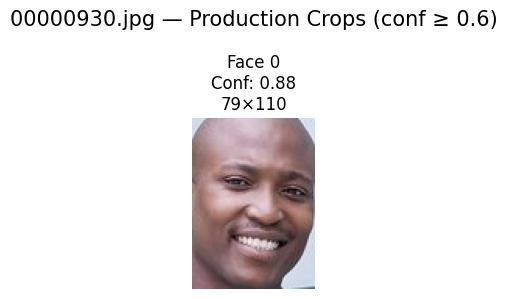

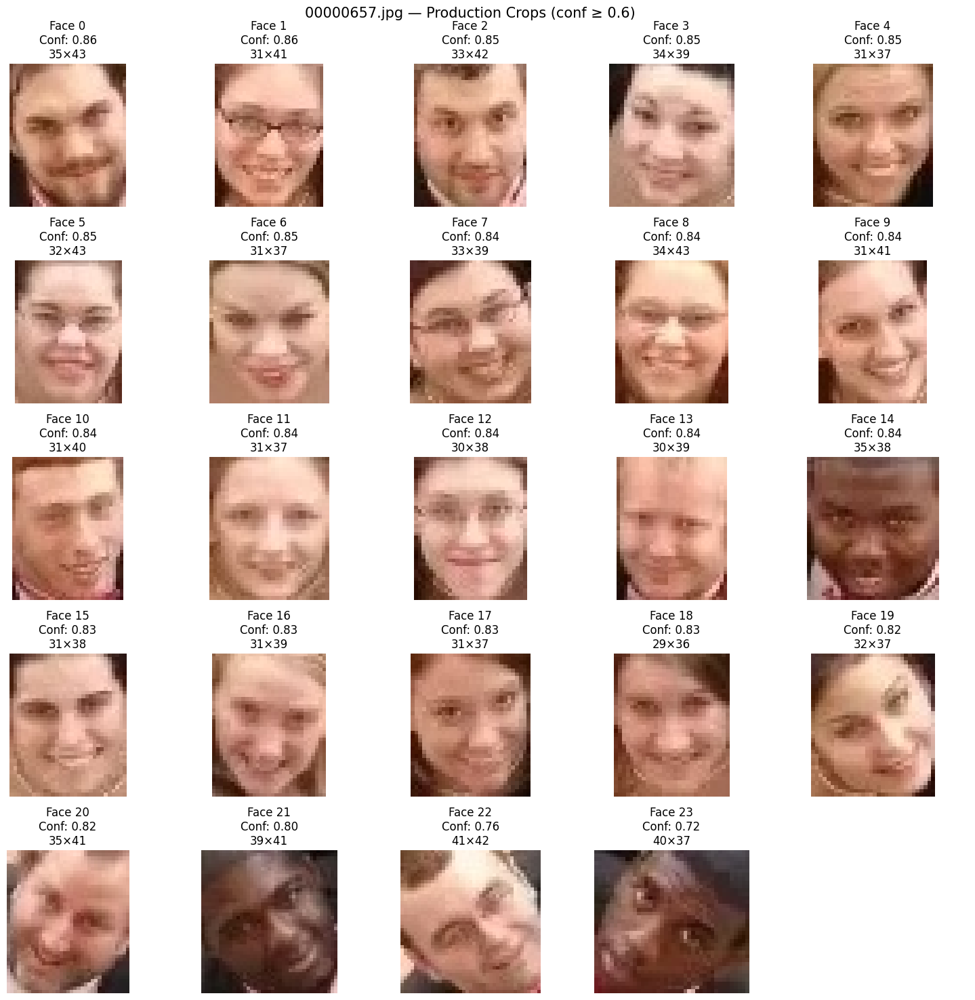

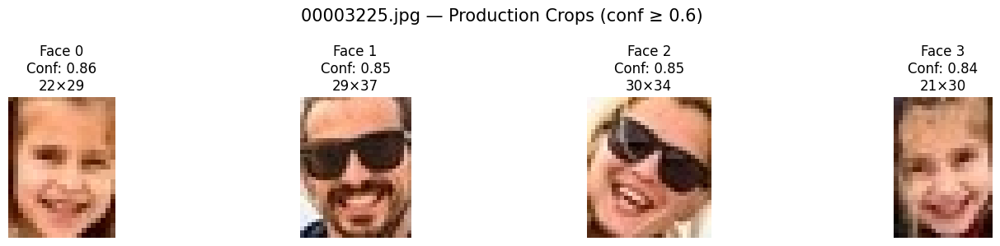

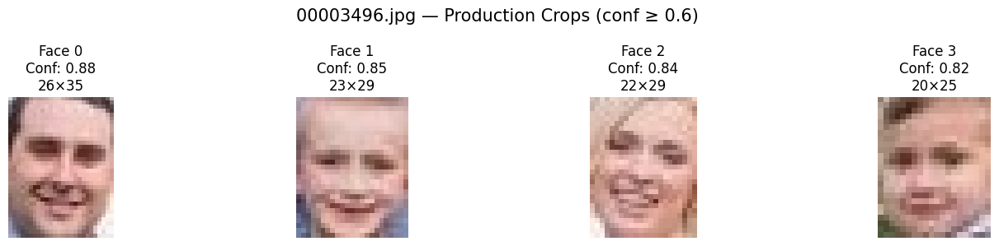

In [ ]:
# Display all production-test crops

for image_name in test_crop_images:

    image_output_dir = (
        TEST_CROP_DIR / Path(image_name).stem
    )

    crop_files = sorted(
        image_output_dir.glob("*.jpg")
    )

    if not crop_files:
        print(f"No crops found for {image_name}")
        continue

    max_display = len(crop_files)

    cols = min(5, max_display)
    rows = (
        max_display + cols - 1
    ) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    image_metadata = test_crop_metadata[
        test_crop_metadata["image_name"] == image_name
    ].reset_index(drop=True)

    for i, crop_path in enumerate(crop_files):

        crop = Image.open(crop_path)

        row = image_metadata[
            image_metadata["face_id"] == i
        ]

        if len(row) > 0:
            confidence = row.iloc[0]["confidence"]
            width = row.iloc[0]["crop_width"]
            height = row.iloc[0]["crop_height"]

            title = (
                f"Face {i}\n"
                f"Conf: {confidence:.2f}\n"
                f"{width}×{height}"
            )
        else:
            title = f"Face {i}"

        axes[i].imshow(crop)
        axes[i].set_title(title)
        axes[i].axis("off")

    fig.suptitle(
        f"{image_name} — Production Crops (conf ≥ {FINAL_CONFIDENCE})",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

In [ ]:
from tqdm.auto import tqdm
from pathlib import Path
import pandas as pd

# ============================================================
# Configuration
# ============================================================

FULL_CROP_DIR = OUTPUT_DIR / "face_crops"
FULL_CROP_DIR.mkdir(parents=True, exist_ok=True)

METADATA_PATH = OUTPUT_DIR / "face_detections.csv"

print("Input image directory :", IMAGE_DIR)
print("Output crop directory :", FULL_CROP_DIR)
print("Confidence threshold  :", FINAL_CONFIDENCE)
print("Image size            :", FINAL_IMAGE_SIZE)


# ============================================================
# Collect all images
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

all_image_paths = sorted([
    p for p in IMAGE_DIR.iterdir()
    if p.is_file() and p.suffix.lower() in image_extensions
])

print("\nTotal images found:", len(all_image_paths))


# ============================================================
# Process images
# ============================================================

all_crop_metadata = []
failed_images = []

for image_path in tqdm(
    all_image_paths,
    desc="Processing images"
):

    try:

        result_df = detect_and_crop_faces(
            image_path=image_path,
            model=model,
            output_dir=FULL_CROP_DIR,
            confidence=FINAL_CONFIDENCE,
            imgsz=FINAL_IMAGE_SIZE
        )

        if not result_df.empty:
            all_crop_metadata.append(result_df)

    except Exception as e:

        failed_images.append({
            "image_name": image_path.name,
            "error": str(e)
        })


# ============================================================
# Combine metadata
# ============================================================

if all_crop_metadata:

    face_detections_df = pd.concat(
        all_crop_metadata,
        ignore_index=True
    )

else:

    face_detections_df = pd.DataFrame()


# ============================================================
# Save metadata
# ============================================================

face_detections_df.to_csv(
    METADATA_PATH,
    index=False
)


# ============================================================
# Save failed-image information
# ============================================================

failed_df = pd.DataFrame(failed_images)

FAILED_PATH = OUTPUT_DIR / "failed_images.csv"

failed_df.to_csv(
    FAILED_PATH,
    index=False
)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 60)
print("BATCH PROCESSING COMPLETE")
print("=" * 60)

print("Images processed :", len(all_image_paths))
print("Images failed    :", len(failed_images))
print("Total face crops :", len(face_detections_df))

print("\nMetadata saved to:")
print(METADATA_PATH)

print("\nFailed-image log saved to:")
print(FAILED_PATH)


Input image directory : /content/drive/MyDrive/Face_Cropping_Project/dataset/images
Output crop directory : /content/drive/MyDrive/Face_Cropping_Project/outputs/face_crops
Confidence threshold  : 0.6
Image size            : 1280

Total images found: 2204


Processing images:   0%|          | 0/2204 [00:00<?, ?it/s]


BATCH PROCESSING COMPLETE
Images processed : 2204
Images failed    : 0
Total face crops : 4374

Metadata saved to:
/content/drive/MyDrive/Face_Cropping_Project/outputs/face_detections.csv

Failed-image log saved to:
/content/drive/MyDrive/Face_Cropping_Project/outputs/failed_images.csv


In [ ]:
import pandas as pd
import numpy as np

# Load the saved detection metadata
face_detections_df = pd.read_csv(METADATA_PATH)

print("=" * 60)
print("DATASET-LEVEL SANITY CHECK")
print("=" * 60)

# ------------------------------------------------------------
# Basic information
# ------------------------------------------------------------

total_crops = len(face_detections_df)

unique_images_with_faces = (
    face_detections_df["image_name"].nunique()
)

print("\nTotal face crops:", total_crops)
print(
    "Unique images with detected faces:",
    unique_images_with_faces
)

print(
    "Total input images:",
    len(all_image_paths)
)

# ------------------------------------------------------------
# Images with zero detections
# ------------------------------------------------------------

all_image_names = {
    p.name for p in all_image_paths
}

detected_image_names = set(
    face_detections_df["image_name"]
)

zero_detection_images = sorted(
    all_image_names - detected_image_names
)

print(
    "\nImages with zero detections:",
    len(zero_detection_images)
)

if zero_detection_images:
    print(
        "First 20 zero-detection images:"
    )
    print(zero_detection_images[:20])

# ------------------------------------------------------------
# Duplicate records
# ------------------------------------------------------------

duplicate_records = face_detections_df.duplicated(
    subset=[
        "image_name",
        "face_id",
        "x1",
        "y1",
        "x2",
        "y2"
    ]
).sum()

print(
    "\nDuplicate detection records:",
    duplicate_records
)

# ------------------------------------------------------------
# Invalid bounding boxes
# ------------------------------------------------------------

invalid_boxes = face_detections_df[
    (face_detections_df["x2"] <= face_detections_df["x1"]) |
    (face_detections_df["y2"] <= face_detections_df["y1"]) |
    (face_detections_df["crop_width"] <= 0) |
    (face_detections_df["crop_height"] <= 0)
]

print(
    "Invalid bounding boxes:",
    len(invalid_boxes)
)

# ------------------------------------------------------------
# Crop dimensions
# ------------------------------------------------------------

print("\nCrop width statistics:")
print(
    face_detections_df["crop_width"].describe()
)

print("\nCrop height statistics:")
print(
    face_detections_df["crop_height"].describe()
)

# ------------------------------------------------------------
# Very small crops
# ------------------------------------------------------------

very_small_crops = face_detections_df[
    (face_detections_df["crop_width"] < 20) |
    (face_detections_df["crop_height"] < 20)
]

print(
    "\nCrops with width OR height < 20 pixels:",
    len(very_small_crops)
)

# ------------------------------------------------------------
# Confidence statistics
# ------------------------------------------------------------

print("\nConfidence statistics:")
print(
    face_detections_df["confidence"].describe()
)

# ------------------------------------------------------------
# Detections per image
# ------------------------------------------------------------

detections_per_image = (
    face_detections_df
    .groupby("image_name")
    .size()
)

print("\nDetections per image:")
print(
    detections_per_image.describe()
)

# ------------------------------------------------------------
# Final summary
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("SANITY CHECK COMPLETE")
print("=" * 60)

DATASET-LEVEL SANITY CHECK

Total face crops: 4374
Unique images with detected faces: 2189
Total input images: 2204

Images with zero detections: 15
First 20 zero-detection images:
['00000959.jpg', '00001104.jpg', '00001273.jpg', '00001556.jpg', '00001763.jpg', '00001794.jpg', '00001914.jpg', '00001987.jpg', '00001994.jpg', '00002249.jpg', '00002847.jpg', '00002970.jpg', '00003010.jpg', '00003428.jpg', '00003502.jpg']

Duplicate detection records: 0
Invalid bounding boxes: 0

Crop width statistics:
count    4374.000000
mean      126.205075
std       112.428966
min         6.000000
25%        56.000000
50%        92.000000
75%       158.000000
max      1208.000000
Name: crop_width, dtype: float64

Crop height statistics:
count    4374.000000
mean      164.347737
std       146.163977
min         7.000000
25%        71.000000
50%       122.000000
75%       206.000000
max      1634.000000
Name: crop_height, dtype: float64

Crops with width OR height < 20 pixels: 68

Confidence statistics:


ZERO-DETECTION IMAGES


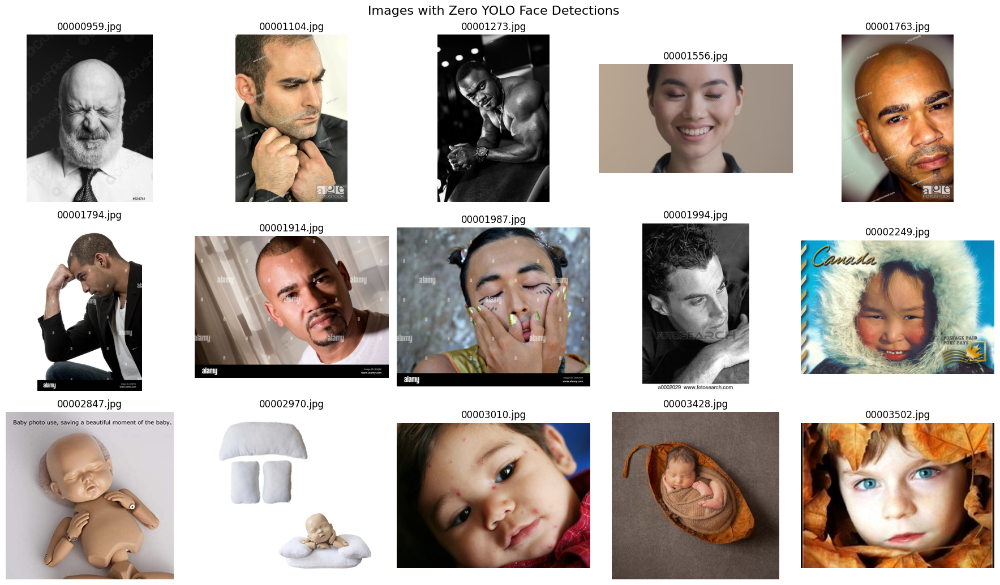


VERY SMALL CROPS
Number of very small crops: 68


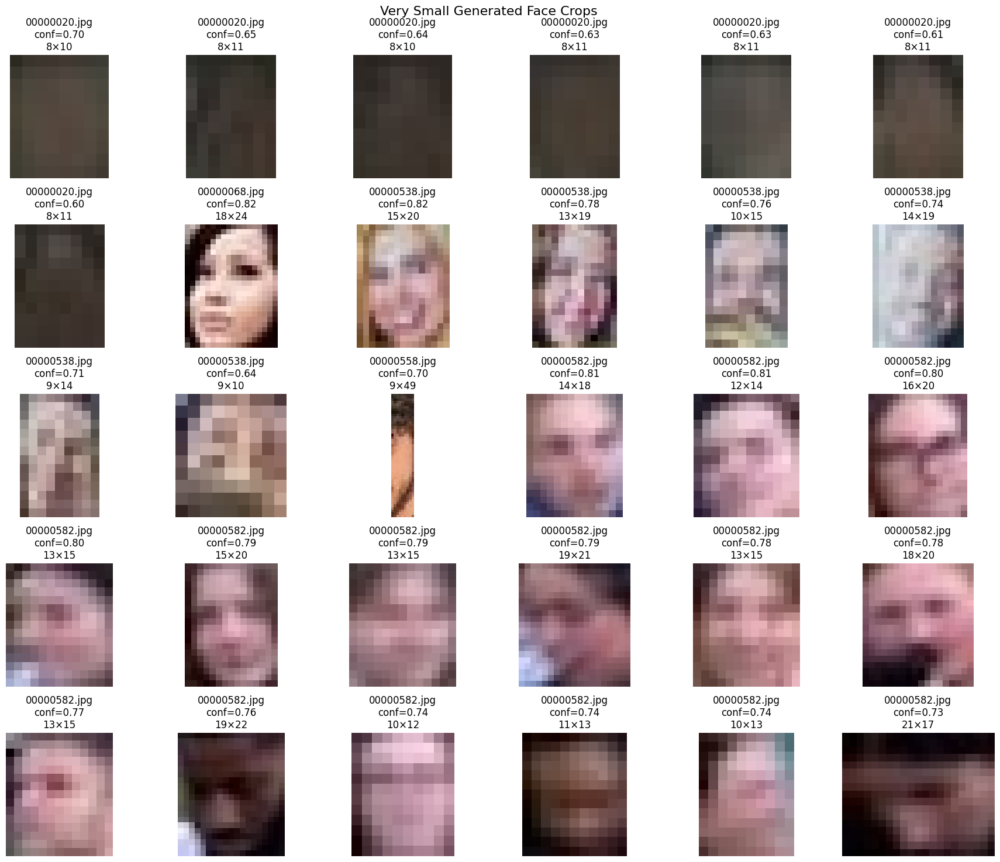


LARGEST CROPS
  image_name  face_id  confidence  crop_width  crop_height
00000177.jpg        0    0.896104        1208         1634
00001709.jpg        0    0.890761        1039         1473
00001477.jpg        0    0.878574        1004         1451
00002556.jpg        0    0.876080        1111         1288
00001340.jpg        0    0.872131         787         1363
00000813.jpg        0    0.745265         859         1175
00003076.jpg        0    0.693257         871         1140
00000561.jpg        0    0.897643         884         1089
00001548.jpg        0    0.861319         795         1167
00001091.jpg        0    0.892600         773         1110
00000561.jpg        1    0.893652         816         1050
00002553.jpg        0    0.909099         802         1062
00002698.jpg        0    0.894854         818         1022
00000561.jpg        2    0.892771         787         1048
00000427.jpg        5    0.719734         792          984
00000866.jpg        0    0.689278        

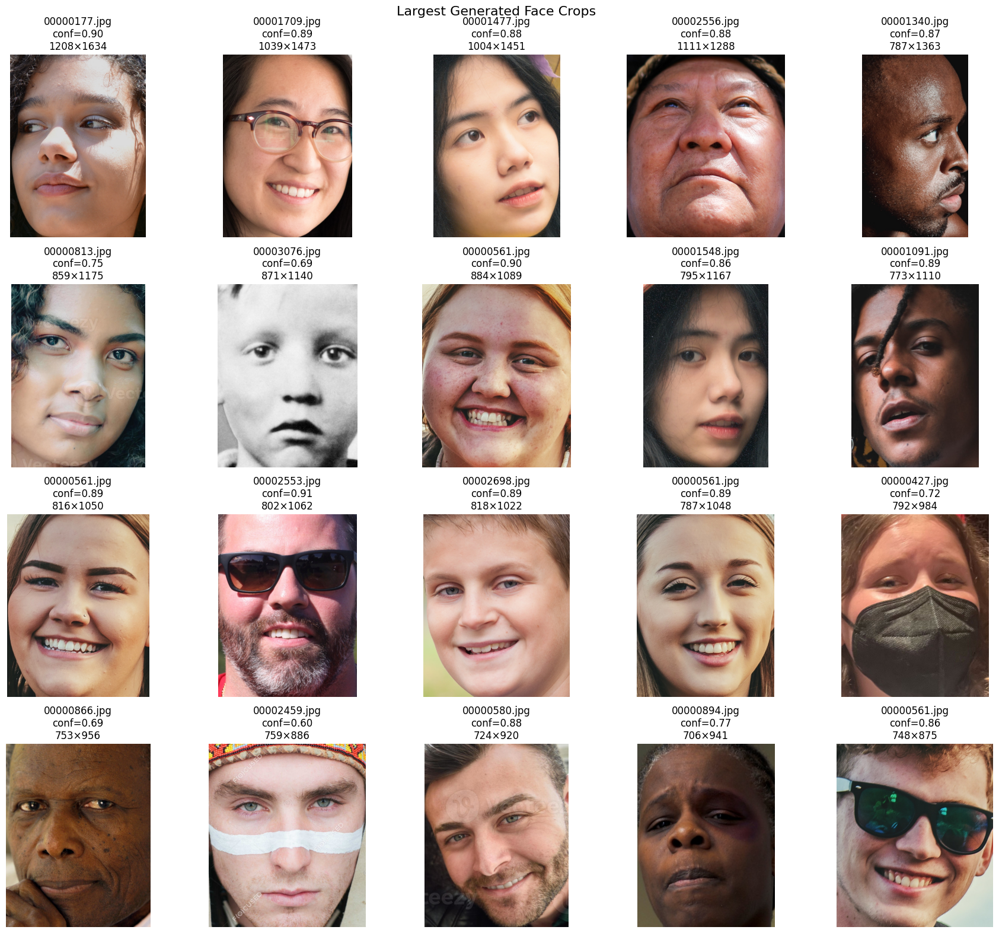

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from pathlib import Path

# ============================================================
# 1. Zero-detection images
# ============================================================

print("=" * 60)
print("ZERO-DETECTION IMAGES")
print("=" * 60)

# Show up to 15 zero-detection images
display_zero = zero_detection_images[:15]

cols = 5
rows = (len(display_zero) + cols - 1) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 3.5 * rows)
)

axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for i, image_name in enumerate(display_zero):

    image_path = IMAGE_DIR / image_name

    image = Image.open(image_path).convert("RGB")

    axes[i].imshow(image)
    axes[i].set_title(image_name)
    axes[i].axis("off")

plt.suptitle(
    "Images with Zero YOLO Face Detections",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. Very small crops
# ============================================================

print("\n" + "=" * 60)
print("VERY SMALL CROPS")
print("=" * 60)

small_crops = face_detections_df[
    (face_detections_df["crop_width"] < 20) |
    (face_detections_df["crop_height"] < 20)
].copy()

print("Number of very small crops:", len(small_crops))

# Display at most 30
small_crops_display = small_crops.head(30)

cols = 6
rows = (
    len(small_crops_display) + cols - 1
) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 3 * rows)
)

axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for i, (_, row) in enumerate(
    small_crops_display.iterrows()
):

    crop_path = Path(row["crop_path"])

    crop = Image.open(crop_path).convert("RGB")

    axes[i].imshow(crop)

    axes[i].set_title(
        f"{row['image_name']}\n"
        f"conf={row['confidence']:.2f}\n"
        f"{row['crop_width']}×{row['crop_height']}"
    )

    axes[i].axis("off")

plt.suptitle(
    "Very Small Generated Face Crops",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ============================================================
# 3. Largest crops
# ============================================================

print("\n" + "=" * 60)
print("LARGEST CROPS")
print("=" * 60)

largest_crops = face_detections_df.copy()

largest_crops["crop_area"] = (
    largest_crops["crop_width"] *
    largest_crops["crop_height"]
)

largest_crops = largest_crops.sort_values(
    "crop_area",
    ascending=False
)

largest_crops_display = largest_crops.head(20)

print(
    largest_crops_display[
        [
            "image_name",
            "face_id",
            "confidence",
            "crop_width",
            "crop_height"
        ]
    ].to_string(index=False)
)

cols = 5
rows = (
    len(largest_crops_display) + cols - 1
) // cols

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(18, 4 * rows)
)

axes = np.array(axes).reshape(-1)

for ax in axes:
    ax.axis("off")

for i, (_, row) in enumerate(
    largest_crops_display.iterrows()
):

    crop_path = Path(row["crop_path"])

    crop = Image.open(crop_path).convert("RGB")

    axes[i].imshow(crop)

    axes[i].set_title(
        f"{row['image_name']}\n"
        f"conf={row['confidence']:.2f}\n"
        f"{row['crop_width']}×{row['crop_height']}"
    )

    axes[i].axis("off")

plt.suptitle(
    "Largest Generated Face Crops",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Step 44 — Investigate zero-detection images
# ============================================================

zero_detection_analysis = []

test_thresholds = [0.25, 0.40, 0.50, 0.60]

for image_name in zero_detection_images:

    image_path = IMAGE_DIR / image_name

    # Read image dimensions
    image = Image.open(image_path)

    row = {
        "image_name": image_name,
        "width": image.width,
        "height": image.height
    }

    for conf_threshold in test_thresholds:

        results = model.predict(
            source=str(image_path),
            conf=conf_threshold,
            imgsz=1280,
            verbose=False
        )

        result = results[0]

        confidences = (
            result.boxes.conf.cpu().numpy()
        )

        row[
            f"detections_{conf_threshold}"
        ] = len(confidences)

        row[
            f"max_conf_{conf_threshold}"
        ] = (
            float(np.max(confidences))
            if len(confidences) > 0
            else 0.0
        )

    zero_detection_analysis.append(row)


zero_detection_df = pd.DataFrame(
    zero_detection_analysis
)

display(zero_detection_df)

,image_name,width,height,detections_0.25,max_conf_0.25,detections_0.4,max_conf_0.4,detections_0.5,max_conf_0.5,detections_0.6,max_conf_0.6
0,00000959.jpg,1125,1500,1,0.383232,0,0.000000,0,0.000000,0,0.0
1,00001104.jpg,700,1050,3,0.512470,1,0.512470,1,0.512470,0,0.0
2,00001273.jpg,417,626,1,0.418112,1,0.418112,0,0.000000,0,0.0
3,00001556.jpg,608,342,2,0.572283,2,0.572283,1,0.572283,0,0.0
4,00001763.jpg,699,1050,2,0.550680,1,0.550680,1,0.550680,0,0.0
5,00001794.jpg,866,1390,1,0.517849,1,0.517849,1,0.517849,0,0.0
6,00001914.jpg,1300,956,3,0.597490,2,0.597490,1,0.597490,0,0.0
7,00001987.jpg,1300,1066,3,0.452865,1,0.452865,0,0.000000,0,0.0
8,00001994.jpg,300,470,1,0.534944,1,0.534944,1,0.534944,0,0.0
9,00002249.jpg,1330,919,1,0.570565,1,0.570565,1,0.570565,0,0.0


In [ ]:
# ============================================================
# Step 45 — Inspect zero-detection images at confidence 0.25
# ============================================================

DIFFICULT_CROP_DIR = OUTPUT_DIR / "difficult_images_conf025"
DIFFICULT_CROP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

difficult_records = []

for image_name in zero_detection_images:

    image_path = IMAGE_DIR / image_name

    results = model.predict(
        source=str(image_path),
        conf=0.25,
        imgsz=1280,
        verbose=False
    )

    result = results[0]

    boxes = result.boxes.xyxy.cpu().numpy()
    confidences = result.boxes.conf.cpu().numpy()

    image = Image.open(
        image_path
    ).convert("RGB")

    image_dir = (
        DIFFICULT_CROP_DIR /
        Path(image_name).stem
    )

    image_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    for face_id, (box, conf) in enumerate(
        zip(boxes, confidences)
    ):

        x1, y1, x2, y2 = box

        x1 = max(0, int(x1))
        y1 = max(0, int(y1))
        x2 = min(image.width, int(x2))
        y2 = min(image.height, int(y2))

        if x2 <= x1 or y2 <= y1:
            continue

        crop = image.crop(
            (x1, y1, x2, y2)
        )

        crop_path = (
            image_dir /
            f"face_{face_id:03d}.jpg"
        )

        crop.save(
            crop_path,
            quality=95
        )

        difficult_records.append({
            "image_name": image_name,
            "face_id": face_id,
            "confidence": float(conf),
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "crop_width": x2 - x1,
            "crop_height": y2 - y1,
            "crop_path": str(crop_path)
        })

difficult_crops_df = pd.DataFrame(
    difficult_records
)

print(
    "Total detections at confidence 0.25:",
    len(difficult_crops_df)
)

display(
    difficult_crops_df.sort_values(
        ["image_name", "confidence"],
        ascending=[True, False]
    )
)

Total detections at confidence 0.25: 31


,image_name,face_id,confidence,x1,y1,x2,y2,crop_width,crop_height,crop_path
0,00000959.jpg,0,0.383232,396,475,847,973,451,498,/content/drive/MyDrive/Face_Cropping_Project/o...
1,00001104.jpg,0,0.512470,154,142,552,639,398,497,/content/drive/MyDrive/Face_Cropping_Project/o...
2,00001104.jpg,1,0.377843,186,535,600,1014,414,479,/content/drive/MyDrive/Face_Cropping_Project/o...
3,00001104.jpg,2,0.343152,160,39,566,497,406,458,/content/drive/MyDrive/Face_Cropping_Project/o...
4,00001273.jpg,0,0.418112,75,145,214,280,139,135,/content/drive/MyDrive/Face_Cropping_Project/o...
5,00001556.jpg,0,0.572283,170,0,410,267,240,267,/content/drive/MyDrive/Face_Cropping_Project/o...
6,00001556.jpg,1,0.404124,171,30,376,296,205,266,/content/drive/MyDrive/Face_Cropping_Project/o...
7,00001763.jpg,0,0.550680,89,349,488,840,399,491,/content/drive/MyDrive/Face_Cropping_Project/o...
8,00001763.jpg,1,0.383783,213,292,657,808,444,516,/content/drive/MyDrive/Face_Cropping_Project/o...
9,00001794.jpg,0,0.517849,270,271,551,582,281,311,/content/drive/MyDrive/Face_Cropping_Project/o...


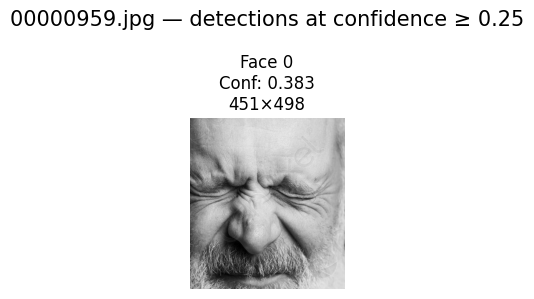

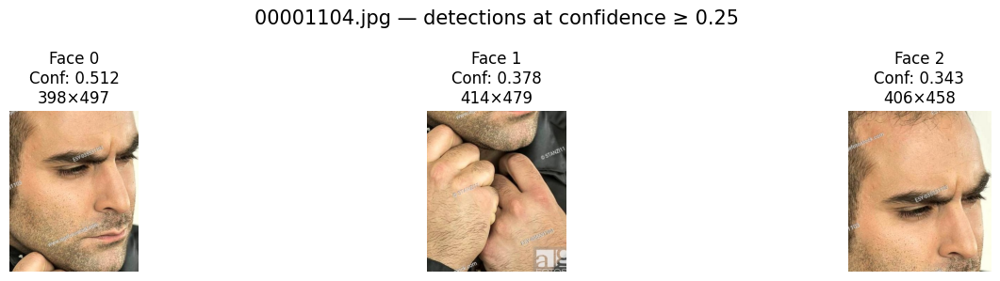

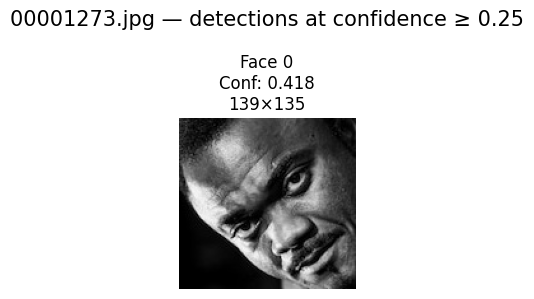

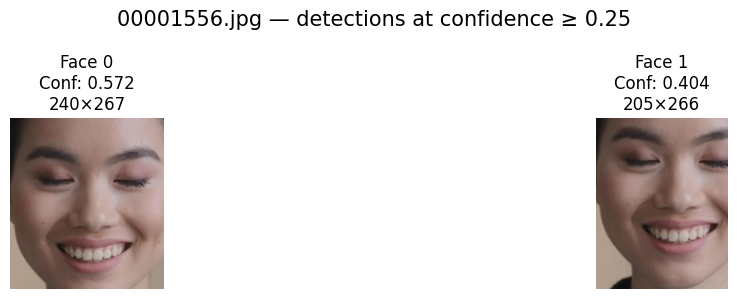

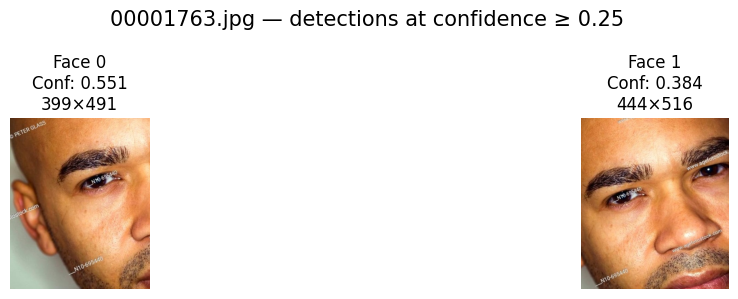

...

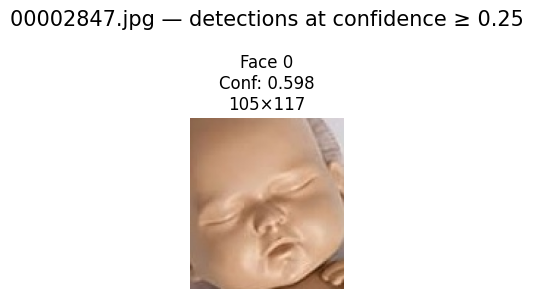

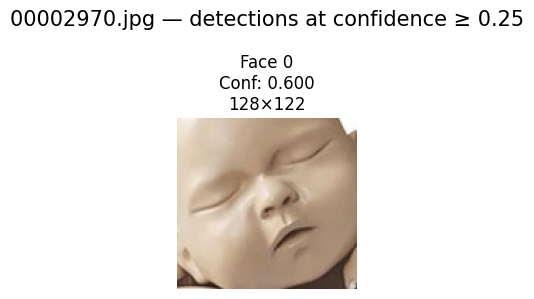

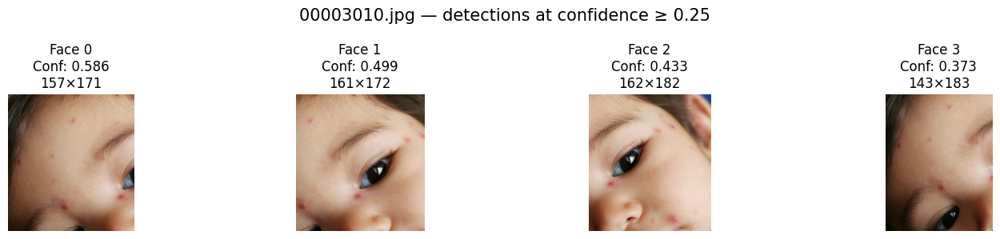

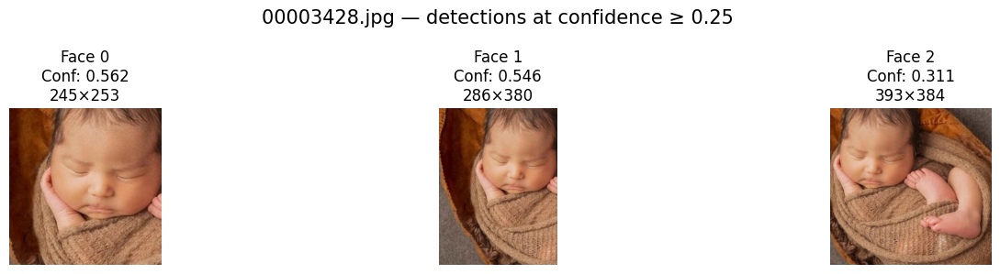

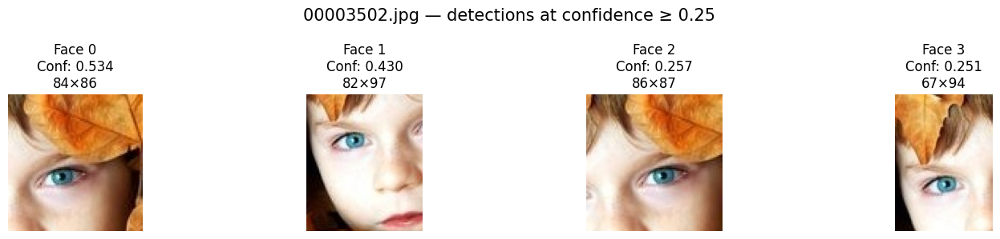

In [ ]:
# ============================================================
# Step 46 — Visualize difficult-image crops
# ============================================================

for image_name in zero_detection_images:

    image_rows = difficult_crops_df[
        difficult_crops_df["image_name"] == image_name
    ].reset_index(drop=True)

    if image_rows.empty:
        continue

    cols = min(5, len(image_rows))
    rows = (
        len(image_rows) + cols - 1
    ) // cols

    fig, axes = plt.subplots(
        rows,
        cols,
        figsize=(15, 3 * rows)
    )

    axes = np.array(axes).reshape(-1)

    for ax in axes:
        ax.axis("off")

    for i, row in image_rows.iterrows():

        crop = Image.open(
            row["crop_path"]
        ).convert("RGB")

        axes[i].imshow(crop)

        axes[i].set_title(
            f"Face {int(row['face_id'])}\n"
            f"Conf: {row['confidence']:.3f}\n"
            f"{int(row['crop_width'])}×"
            f"{int(row['crop_height'])}"
        )

        axes[i].axis("off")

    fig.suptitle(
        f"{image_name} — detections at confidence ≥ 0.25",
        fontsize=15
    )

    plt.tight_layout()
    plt.show()

In [ ]:
# ============================================================
# Step 47 — Minimum crop-area filtering experiment
# ============================================================

# We already generated difficult_crops_df at confidence 0.25
# in Step 45.

difficult_crops_df = difficult_crops_df.copy()

difficult_crops_df["crop_area"] = (
    difficult_crops_df["crop_width"] *
    difficult_crops_df["crop_height"]
)

area_thresholds = [0, 300, 500, 600, 800, 1000]

area_results = []

for threshold in area_thresholds:

    filtered = difficult_crops_df[
        difficult_crops_df["crop_area"] >= threshold
    ]

    area_results.append({
        "min_area": threshold,
        "detections_remaining": len(filtered),
        "detections_removed": (
            len(difficult_crops_df) - len(filtered)
        ),
        "images_with_detections": (
            filtered["image_name"].nunique()
        )
    })

area_comparison_df = pd.DataFrame(area_results)

display(area_comparison_df)

,min_area,detections_remaining,detections_removed,images_with_detections
0,0,31,0,15
1,300,31,0,15
2,500,31,0,15
3,600,31,0,15
4,800,31,0,15
5,1000,31,0,15


In [ ]:
from tqdm.auto import tqdm
from pathlib import Path
import pandas as pd

# ============================================================
# Configuration
# ============================================================

CONF025 = 0.25
IMG_SIZE = 1280

FULL_CROP_DIR_025 = (
    OUTPUT_DIR / "face_crops_conf025"
)

FULL_CROP_DIR_025.mkdir(
    parents=True,
    exist_ok=True
)

METADATA_PATH_025 = (
    OUTPUT_DIR / "face_detections_conf025.csv"
)

FAILED_PATH_025 = (
    OUTPUT_DIR / "failed_images_conf025.csv"
)


print("Input image directory :", IMAGE_DIR)
print("Output crop directory :", FULL_CROP_DIR_025)
print("Confidence threshold  :", CONF025)
print("Image size            :", IMG_SIZE)


# ============================================================
# Collect images
# ============================================================

image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".bmp",
    ".webp"
}

all_image_paths = sorted([
    p for p in IMAGE_DIR.iterdir()
    if p.is_file()
    and p.suffix.lower() in image_extensions
])

print("\nTotal images found:", len(all_image_paths))


# ============================================================
# Process complete dataset
# ============================================================

all_crop_metadata_025 = []
failed_images_025 = []

for image_path in tqdm(
    all_image_paths,
    desc="Processing images @ conf=0.25"
):

    try:

        result_df = detect_and_crop_faces(
            image_path=image_path,
            model=model,
            output_dir=FULL_CROP_DIR_025,
            confidence=CONF025,
            imgsz=IMG_SIZE
        )

        if not result_df.empty:
            all_crop_metadata_025.append(
                result_df
            )

    except Exception as e:

        failed_images_025.append({
            "image_name": image_path.name,
            "error": str(e)
        })


# ============================================================
# Combine metadata
# ============================================================

if all_crop_metadata_025:

    face_detections_df_025 = pd.concat(
        all_crop_metadata_025,
        ignore_index=True
    )

else:

    face_detections_df_025 = pd.DataFrame()


# ============================================================
# Save metadata
# ============================================================

face_detections_df_025.to_csv(
    METADATA_PATH_025,
    index=False
)


# ============================================================
# Save failure log
# ============================================================

failed_df_025 = pd.DataFrame(
    failed_images_025
)

failed_df_025.to_csv(
    FAILED_PATH_025,
    index=False
)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 60)
print("CONFIDENCE 0.25 BATCH PROCESSING COMPLETE")
print("=" * 60)

print(
    "Images processed :",
    len(all_image_paths)
)

print(
    "Images failed    :",
    len(failed_images_025)
)

print(
    "Total face crops :",
    len(face_detections_df_025)
)

print("\nMetadata saved to:")
print(METADATA_PATH_025)

print("\nFailed-image log saved to:")
print(FAILED_PATH_025)

Input image directory : /content/drive/MyDrive/Face_Cropping_Project/dataset/images
Output crop directory : /content/drive/MyDrive/Face_Cropping_Project/outputs/face_crops_conf025
Confidence threshold  : 0.25
Image size            : 1280

Total images found: 2204


Processing images @ conf=0.25:   0%|          | 0/2204 [00:00<?, ?it/s]


CONFIDENCE 0.25 BATCH PROCESSING COMPLETE
Images processed : 2204
Images failed    : 0
Total face crops : 4978

Metadata saved to:
/content/drive/MyDrive/Face_Cropping_Project/outputs/face_detections_conf025.csv

Failed-image log saved to:
/content/drive/MyDrive/Face_Cropping_Project/outputs/failed_images_conf025.csv


In [62]:
# Step 1: Final sanity check for confidence = 0.25

df = pd.read_csv(METADATA_PATH_025)

print("=" * 60)
print("FINAL DATASET SANITY CHECK — CONFIDENCE 0.25")
print("=" * 60)

print("\nTotal face crops:", len(df))
print("Unique images with detections:", df["image_name"].nunique())
print("Total input images:", len(all_image_paths))
print("Images with zero detections:",
      len(all_image_paths) - df["image_name"].nunique())

print("\nDuplicate detection records:", df.duplicated().sum())

# Bounding-box validity
invalid_boxes = (
    (df["x2"] <= df["x1"]) |
    (df["y2"] <= df["y1"])
).sum()

print("Invalid bounding boxes:", invalid_boxes)

# Confidence statistics
print("\nConfidence statistics:")
print(df["confidence"].describe())

# Crop dimensions
print("\nCrop width statistics:")
print(df["crop_width"].describe())

print("\nCrop height statistics:")
print(df["crop_height"].describe())

# Very small crops
tiny_crops = (
    (df["crop_width"] < 20) |
    (df["crop_height"] < 20)
).sum()

print("\nCrops with width OR height < 20:", tiny_crops)

# Detections per image
detections_per_image = df.groupby("image_name").size()

print("\nDetections per image:")
print(detections_per_image.describe())

print("\nMaximum detections in one image:",
      detections_per_image.max())

print("\n" + "=" * 60)
print("SANITY CHECK COMPLETE")
print("=" * 60)

FINAL DATASET SANITY CHECK — CONFIDENCE 0.25

Total face crops: 4978
Unique images with detections: 2204
Total input images: 2204
Images with zero detections: 0

Duplicate detection records: 0
Invalid bounding boxes: 0

Confidence statistics:
count    4978.000000
mean        0.799920
std         0.151286
min         0.250058
25%         0.818450
50%         0.859352
75%         0.880116
max         0.956446
Name: confidence, dtype: float64

Crop width statistics:
count    4978.000000
mean      121.805143
std       118.968170
min         3.000000
25%        47.000000
50%        87.000000
75%       156.000000
max      1479.000000
Name: crop_width, dtype: float64

Crop height statistics:
count    4978.000000
mean      157.476898
std       153.418392
min         3.000000
25%        61.000000
50%       114.000000
75%       202.000000
max      2221.000000
Name: crop_height, dtype: float64

Crops with width OR height < 20: 422

Detections per image:
count    2204.000000
mean        2.258621
s

In [63]:
# Step 2A: Find images with unusually large numbers of detections

df = pd.read_csv(METADATA_PATH_025)

detections_per_image = (
    df.groupby("image_name")
      .size()
      .sort_values(ascending=False)
)

print("=" * 60)
print("TOP IMAGES BY NUMBER OF DETECTED FACES")
print("=" * 60)

print(detections_per_image.head(20))

print("\nImages with more than 20 detections:",
      (detections_per_image > 20).sum())

print("Images with more than 50 detections:",
      (detections_per_image > 50).sum())

print("Images with more than 100 detections:",
      (detections_per_image > 100).sum())

# Show metadata for the image with maximum detections
max_image = detections_per_image.index[0]
max_count = detections_per_image.iloc[0]

print("\n" + "=" * 60)
print("IMAGE WITH MAXIMUM DETECTIONS")
print("=" * 60)

print("Image:", max_image)
print("Detections:", max_count)

max_image_df = df[df["image_name"] == max_image].copy()

print("\nConfidence statistics for this image:")
print(max_image_df["confidence"].describe())

print("\nLowest-confidence detections:")
print(
    max_image_df[
        ["face_id", "confidence", "x1", "y1", "x2", "y2",
         "crop_width", "crop_height"]
    ]
    .sort_values("confidence")
    .head(20)
)

TOP IMAGES BY NUMBER OF DETECTED FACES
image_name
00000020.jpg    300
00000582.jpg     86
00002482.jpg     40
00002866.jpg     37
00002726.jpg     27
00000657.jpg     25
00000737.jpg     23
00001474.jpg     22
00002456.jpg     20
00002926.jpg     20
00002045.jpg     18
00002805.jpg     17
00000508.jpg     16
00003172.jpg     16
00003165.jpg     16
00003090.jpg     13
00003287.jpg     13
00003231.jpg     13
00000578.jpg     13
00002517.jpg     13
dtype: int64

Images with more than 20 detections: 8
Images with more than 50 detections: 2
Images with more than 100 detections: 1

IMAGE WITH MAXIMUM DETECTIONS
Image: 00000020.jpg
Detections: 300

Confidence statistics for this image:
count    300.000000
mean       0.447343
std        0.072954
min        0.344562
25%        0.392417
50%        0.435662
75%        0.488481
max        0.896678
Name: confidence, dtype: float64

Lowest-confidence detections:
     face_id  confidence   x1   y1   x2   y2  crop_width  crop_height
310      299    0.

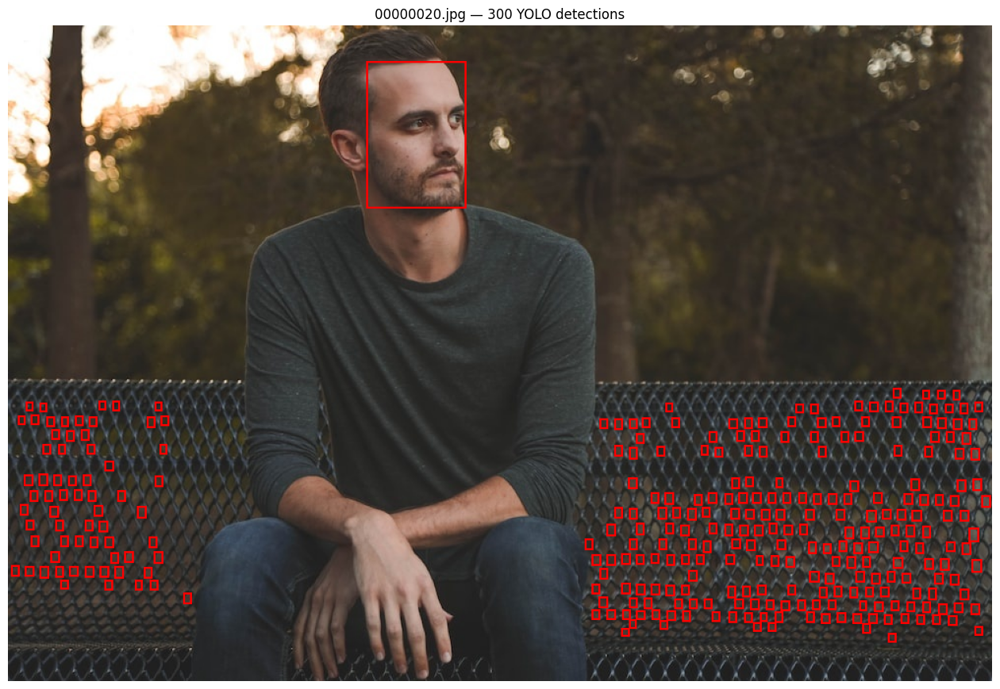

In [64]:
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

# Load the extreme outlier image
outlier_name = "00000020.jpg"
outlier_path = IMAGE_DIR / outlier_name

img = Image.open(outlier_path).convert("RGB")
draw = ImageDraw.Draw(img)

# Get detections for this image
outlier_df = df[df["image_name"] == outlier_name].copy()

# Draw all detected boxes
for _, row in outlier_df.iterrows():
    x1 = int(row["x1"])
    y1 = int(row["y1"])
    x2 = int(row["x2"])
    y2 = int(row["y2"])

    draw.rectangle(
        [x1, y1, x2, y2],
        outline="red",
        width=2
    )

# Display
plt.figure(figsize=(16, 12))
plt.imshow(img)
plt.axis("off")
plt.title(f"{outlier_name} — {len(outlier_df)} YOLO detections")
plt.show()

In [65]:
# Step 2B: Analyze bounding-box area distribution
# No images will be changed or deleted.

df = pd.read_csv(METADATA_PATH_025)

# Calculate bounding-box area
df["face_area"] = (
    (df["x2"] - df["x1"]) *
    (df["y2"] - df["y1"])
)

print("=" * 70)
print("BOUNDING-BOX AREA ANALYSIS")
print("=" * 70)

print("\nOverall face-area statistics:")
print(df["face_area"].describe())

# Candidate area thresholds
thresholds = [50, 100, 200, 300, 500, 800, 1000, 1500, 2000]

print("\n" + "-" * 70)
print("EFFECT OF DIFFERENT MINIMUM AREA THRESHOLDS")
print("-" * 70)

print(
    f"{'Min Area':>10} | "
    f"{'Remaining':>10} | "
    f"{'Removed':>10} | "
    f"{'Images Lost':>12}"
)

print("-" * 70)

total_images = df["image_name"].nunique()

for threshold in thresholds:

    filtered = df[df["face_area"] >= threshold]

    remaining = len(filtered)
    removed = len(df) - remaining
    images_remaining = filtered["image_name"].nunique()
    images_lost = total_images - images_remaining

    print(
        f"{threshold:>10} | "
        f"{remaining:>10} | "
        f"{removed:>10} | "
        f"{images_lost:>12}"
    )

# Specifically inspect the extreme outlier
outlier = df[df["image_name"] == "00000020.jpg"].copy()

print("\n" + "=" * 70)
print("00000020.jpg AREA DISTRIBUTION")
print("=" * 70)

print(outlier["face_area"].describe())

print("\nDetections remaining at each area threshold:")

for threshold in thresholds:
    count = (outlier["face_area"] >= threshold).sum()
    print(f"Minimum area {threshold:>4}: {count:>3} detections")

BOUNDING-BOX AREA ANALYSIS

Overall face-area statistics:
count    4.978000e+03
mean     3.708220e+04
std      1.025626e+05
min      9.000000e+00
25%      2.901750e+03
50%      9.948000e+03
75%      3.126600e+04
max      3.284859e+06
Name: face_area, dtype: float64

----------------------------------------------------------------------
EFFECT OF DIFFERENT MINIMUM AREA THRESHOLDS
----------------------------------------------------------------------
  Min Area |  Remaining |    Removed |  Images Lost
----------------------------------------------------------------------
        50 |       4958 |         20 |            0
       100 |       4652 |        326 |            0
       200 |       4601 |        377 |            0
       300 |       4589 |        389 |            0
       500 |       4560 |        418 |            0
       800 |       4469 |        509 |            5
      1000 |       4394 |        584 |           12
      1500 |       4175 |        803 |           44
      20

In [66]:
# Step 2C: Inspect small-area detections before choosing a filter

df = pd.read_csv(METADATA_PATH_025)

df["face_area"] = (
    (df["x2"] - df["x1"]) *
    (df["y2"] - df["y1"])
)

small_df = df[df["face_area"] < 200].copy()

print("=" * 70)
print("SMALL-AREA DETECTIONS")
print("=" * 70)

print("Total detections with area < 200:", len(small_df))
print("Area < 100:", (small_df["face_area"] < 100).sum())
print("Area 100–199:", ((small_df["face_area"] >= 100) &
                       (small_df["face_area"] < 200)).sum())

print("\nImages containing area < 100 detections:",
      small_df[small_df["face_area"] < 100]["image_name"].nunique())

print("Images containing area 100–199 detections:",
      small_df[
          (small_df["face_area"] >= 100) &
          (small_df["face_area"] < 200)
      ]["image_name"].nunique())

# Lowest-area detections
print("\nLowest-area detections:")
print(
    small_df[
        ["image_name", "face_id", "confidence",
         "x1", "y1", "x2", "y2",
         "crop_width", "crop_height", "face_area"]
    ]
    .sort_values("face_area")
    .head(30)
)

# Save a small sample for visual inspection
sample_small = small_df.sample(
    n=min(20, len(small_df)),
    random_state=42
)

print("\nRandom sample selected for visual inspection:")
print(
    sample_small[
        ["image_name", "face_id", "confidence",
         "crop_width", "crop_height", "face_area"]
    ].to_string(index=False)
)

SMALL-AREA DETECTIONS
Total detections with area < 200: 377
Area < 100: 326
Area 100–199: 51

Images containing area < 100 detections: 7
Images containing area 100–199 detections: 8

Lowest-area detections:
        image_name  face_id  confidence   x1   y1   x2   y2  crop_width  \
3125  00002428.jpg        3    0.419274  168  133  171  136           3   
3130  00002428.jpg        8    0.258362  159  137  162  141           3   
3127  00002428.jpg        5    0.283644  352  147  356  151           4   
1076  00000582.jpg       77    0.286732  633   37  637   42           4   
3129  00002428.jpg        7    0.263057  205  134  209  139           4   
3128  00002428.jpg        6    0.269405  313  156  317  161           4   
1077  00000582.jpg       78    0.282720  435   47  439   53           4   
3123  00002428.jpg        1    0.599636  254  135  259  141           5   
3124  00002428.jpg        2    0.447434  196  138  201  145           5   
1082  00000582.jpg       83    0.257490  68

In [68]:
from pathlib import Path
import pandas as pd
import shutil

# ------------------------------------------------------------
# FINAL FACE-CROP CONFIGURATION
# ------------------------------------------------------------

FINAL_CONFIDENCE = 0.25
FINAL_MIN_AREA = 200
FINAL_IMAGE_SIZE = 1280

SOURCE_METADATA = METADATA_PATH_025
SOURCE_CROP_DIR = FULL_CROP_DIR_025

FINAL_CROP_DIR = OUTPUT_DIR / "final_face_crops"
FINAL_METADATA_PATH = OUTPUT_DIR / "final_face_detections.csv"

FINAL_CROP_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# LOAD DETECTIONS
# ------------------------------------------------------------

df = pd.read_csv(SOURCE_METADATA)

# Calculate bounding-box area
df["face_area"] = (
    (df["x2"] - df["x1"]) *
    (df["y2"] - df["y1"])
)

print("=" * 70)
print("CREATING FINAL FACE-CROP DATASET")
print("=" * 70)

print("\nOriginal detections:", len(df))

# ------------------------------------------------------------
# APPLY FINAL AREA FILTER
# ------------------------------------------------------------

final_df = df[df["face_area"] >= FINAL_MIN_AREA].copy()

print("Detections after area filter:", len(final_df))
print("Detections removed:", len(df) - len(final_df))

print(
    "Images with detections:",
    final_df["image_name"].nunique()
)

print(
    "Images lost completely:",
    df["image_name"].nunique() -
    final_df["image_name"].nunique()
)

# ------------------------------------------------------------
# COPY FINAL CROPS
# ------------------------------------------------------------

copied = 0
missing = 0

for _, row in final_df.iterrows():

    source_path = Path(row["crop_path"])

    # Create image-specific directory
    image_stem = Path(row["image_name"]).stem

    image_output_dir = FINAL_CROP_DIR / image_stem
    image_output_dir.mkdir(parents=True, exist_ok=True)

    destination_path = (
        image_output_dir /
        source_path.name
    )

    if source_path.exists():
        shutil.copy2(source_path, destination_path)
        copied += 1

        # Update path in metadata
        final_df.loc[
            final_df.index == row.name,
            "crop_path"
        ] = str(destination_path)

    else:
        missing += 1

# ------------------------------------------------------------
# SAVE FINAL METADATA
# ------------------------------------------------------------

final_df.to_csv(
    FINAL_METADATA_PATH,
    index=False
)

# ------------------------------------------------------------
# FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL FACE-CROP DATASET CREATED")
print("=" * 70)

print("YOLO model              : YOLO11n-face")
print("Confidence threshold    :", FINAL_CONFIDENCE)
print("Image size              :", FINAL_IMAGE_SIZE)
print("Minimum box area        :", FINAL_MIN_AREA)
print()
print("Original detections     :", len(df))
print("Final face crops        :", len(final_df))
print("Removed detections      :", len(df) - len(final_df))
print("Images with detections  :", final_df["image_name"].nunique())
print("Images completely lost  :",
      df["image_name"].nunique() -
      final_df["image_name"].nunique())
print("Crops successfully copied:", copied)
print("Missing source crops    :", missing)

print("\nFinal crop directory:")
print(FINAL_CROP_DIR)

print("\nFinal metadata:")
print(FINAL_METADATA_PATH)

CREATING FINAL FACE-CROP DATASET

Original detections: 4978
Detections after area filter: 4601
Detections removed: 377
Images with detections: 2204
Images lost completely: 0

FINAL FACE-CROP DATASET CREATED
YOLO model              : YOLO11n-face
Confidence threshold    : 0.25
Image size              : 1280
Minimum box area        : 200

Original detections     : 4978
Final face crops        : 4601
Removed detections      : 377
Images with detections  : 2204
Images completely lost  : 0
Crops successfully copied: 4601
Missing source crops    : 0

Final crop directory:
/content/drive/MyDrive/Face_Cropping_Project/outputs/final_face_crops

Final metadata:
/content/drive/MyDrive/Face_Cropping_Project/outputs/final_face_detections.csv
